# Processing MEX2 NEXAFS

## Imports

In [1]:
## Imports
import pathlib
import sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from tqdm.auto import tqdm
from scipy import optimize
from matplotlib.ticker import MultipleLocator

basePath = pathlib.Path('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/data_analysis/rsoxs_suite')
nexafsFxnsPath = basePath.joinpath('misc_older_work/nexafs_analysis')
sys.path.append(str(nexafsFxnsPath))
import nexafs_fxns as nf  # custom nexafs functions used throughout this notebook

## Define paths & sample name dictionary

In [2]:
# Define paths
rawPath = basePath.joinpath('local_data/MEX2_SKedge_NF/raw_data')
outPath = basePath.joinpath('local_data/MEX2_SKedge_NF')
# zarrPath = outPath.joinpath('local_data/MEX2_SKedge_NF/')

## Load MEX2 nexafs data into xarray dataset

In [3]:
[f.name for f in sorted(rawPath.glob('MEX*xdi'))]

['MEX2_13367_processed.xdi',
 'MEX2_13368_processed.xdi',
 'MEX2_13369_processed.xdi',
 'MEX2_13370_processed.xdi',
 'MEX2_13371_processed.xdi',
 'MEX2_13372_processed.xdi',
 'MEX2_13373_processed.xdi',
 'MEX2_13374_processed.xdi',
 'MEX2_13375_processed.xdi',
 'MEX2_13376_processed.xdi',
 'MEX2_13377_processed.xdi',
 'MEX2_13378_processed.xdi']

In [4]:
files = sorted(rawPath.glob('MEX*xdi'))

nf_samp_DS_list = []
for file in files[:]:
    # Get metadata
    with file.open('r') as f:
        lines = list(f.readlines())
    sample_ID = lines[33].split(' ')[1]
    theta = int(lines[33].split(' ')[2])
    columns = [line.split(' ')[-1][:-1] for line in lines[12:21]]

    # Get data
    all_data = np.loadtxt(file)
    energies = all_data.T[0]

    # Put in dataset
    nf_samp_DS = xr.Dataset()
    for column, data in zip(columns[1:], all_data.T[1:]):
        # print(energies)
        nf_samp_DS[column] = xr.DataArray(
            data=data.reshape(data.size, 1, 1), 
            coords={'energy': energies, 'sample_ID':[sample_ID], 'theta': [theta]}
        )

    # Interpolate dataset to standard energy to ensure compatability across samples
    interp_energies = np.linspace(2460, 2560, 2000)  # sulfur
    nf_samp_DS = nf_samp_DS.interp({'energy': interp_energies})
    nf_samp_DS_list.append(nf_samp_DS)

nf_DS = xr.combine_by_coords(nf_samp_DS_list)
nf_DS

<xarray.Dataset>
Dimensions:       (sample_ID: 4, theta: 3, energy: 2000)
Coordinates:
  * sample_ID     (sample_ID) <U5 'Al_01' 'Al_02' 'Al_03' 'Al_04'
  * theta         (theta) int64 35 55 90
  * energy        (energy) float64 2.46e+03 2.46e+03 ... 2.56e+03 2.56e+03
Data variables:
    bragg         (energy, sample_ID, theta) float64 53.4 53.4 ... 50.48 50.48
    count_time    (energy, sample_ID, theta) float64 1.0 1.0 1.0 ... 1.0 1.0 1.0
    BIM           (energy, sample_ID, theta) float64 3.018 3.013 ... 3.105 3.103
    i0            (energy, sample_ID, theta) float64 1.706 1.711 ... 1.883 1.891
    SampleDrain   (energy, sample_ID, theta) float64 0.4575 0.6401 ... 1.71 1.39
    roi_avg_kCPS  (energy, sample_ID, theta) float64 0.1948 0.153 ... 6.94 5.592
    ifluor        (energy, sample_ID, theta) float64 198.4 155.6 ... 5.641e+03
    mufluor       (energy, sample_ID, theta) float64 116.3 90.92 ... 2.983e+03

In [5]:
dnorm_TEY_DA = nf_DS['SampleDrain'] / nf_DS['i0']  # i0 normalization
dnorm_TEY_DA = dnorm_TEY_DA - dnorm_TEY_DA.sel(energy=slice(2461,2468)).mean('energy')  # pre edge normalization
dnorm_TEY_DA = dnorm_TEY_DA / dnorm_TEY_DA.sel(energy=slice(2510,2530)).mean('energy')  # post edge normalization
nf_DS['dnorm_TEY'] = dnorm_TEY_DA

dnorm_PFY_DA = nf_DS['ifluor'] / nf_DS['i0']  # i0 normalization
dnorm_PFY_DA = dnorm_PFY_DA - dnorm_PFY_DA.sel(energy=slice(2461,2468)).mean('energy')  # pre edge normalization
dnorm_PFY_DA = dnorm_PFY_DA / dnorm_PFY_DA.sel(energy=slice(2510,2530)).mean('energy')  # post edge normalization
nf_DS['dnorm_PFY'] = dnorm_PFY_DA

nf_DS

<xarray.Dataset>
Dimensions:       (sample_ID: 4, theta: 3, energy: 2000)
Coordinates:
  * sample_ID     (sample_ID) <U5 'Al_01' 'Al_02' 'Al_03' 'Al_04'
  * theta         (theta) int64 35 55 90
  * energy        (energy) float64 2.46e+03 2.46e+03 ... 2.56e+03 2.56e+03
Data variables:
    bragg         (energy, sample_ID, theta) float64 53.4 53.4 ... 50.48 50.48
    count_time    (energy, sample_ID, theta) float64 1.0 1.0 1.0 ... 1.0 1.0 1.0
    BIM           (energy, sample_ID, theta) float64 3.018 3.013 ... 3.105 3.103
    i0            (energy, sample_ID, theta) float64 1.706 1.711 ... 1.883 1.891
    SampleDrain   (energy, sample_ID, theta) float64 0.4575 0.6401 ... 1.71 1.39
    roi_avg_kCPS  (energy, sample_ID, theta) float64 0.1948 0.153 ... 6.94 5.592
    ifluor        (energy, sample_ID, theta) float64 198.4 155.6 ... 5.641e+03
    mufluor       (energy, sample_ID, theta) float64 116.3 90.92 ... 2.983e+03
    dnorm_TEY     (energy, sample_ID, theta) float64 -0.00776 ... 0.9666
    dnorm_PFY     (energy, sample_ID, theta) float64 -0.008022 ... 0.9863

## Quick Plotting

In [6]:
sn = {
    'Al_01': 'PM6 CF + 0.0% CN',
    'Al_02': 'PM6 CF + 0.5% CN',
    'Al_03': 'PM6 CF + 1.0% CN',
    'Al_04': 'PM6 CF + 5.0% CN',
}

CN_val = {
    'Al_01': '0.0% CN',
    'Al_02': '0.5% CN',
    'Al_03': '1.0% CN',
    'Al_04': '5.0% CN',
}

### Sample across theta

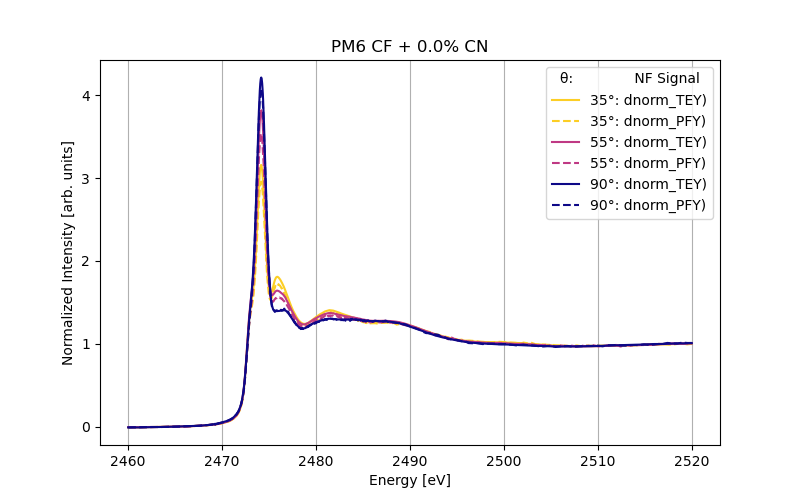

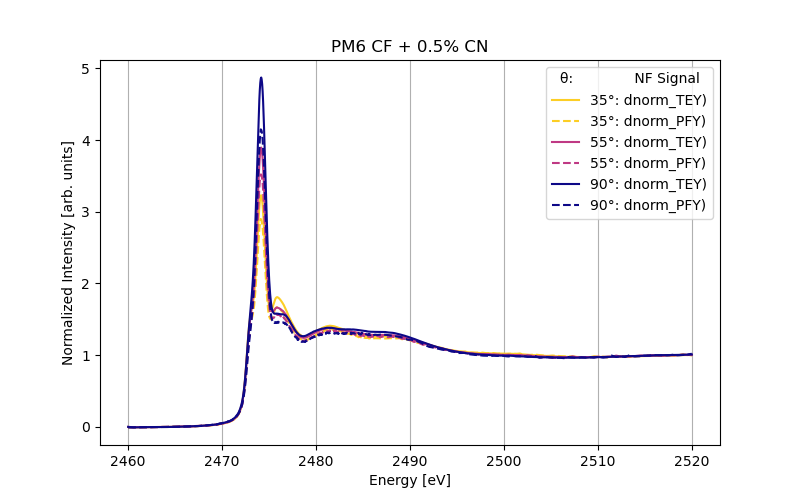

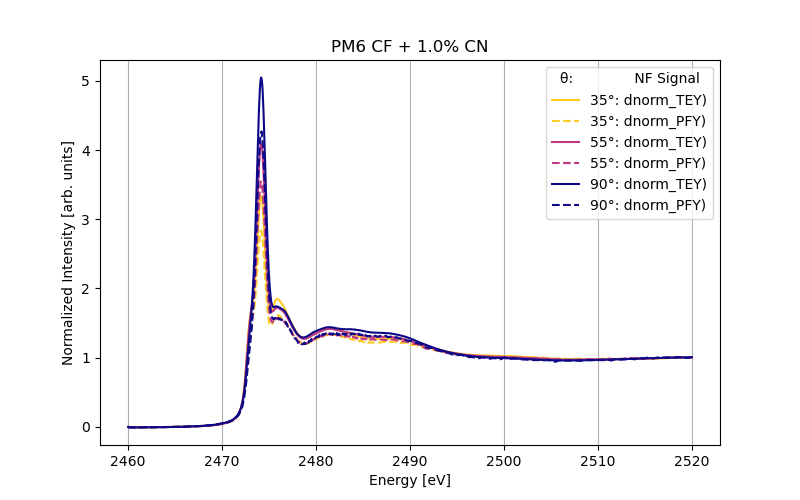

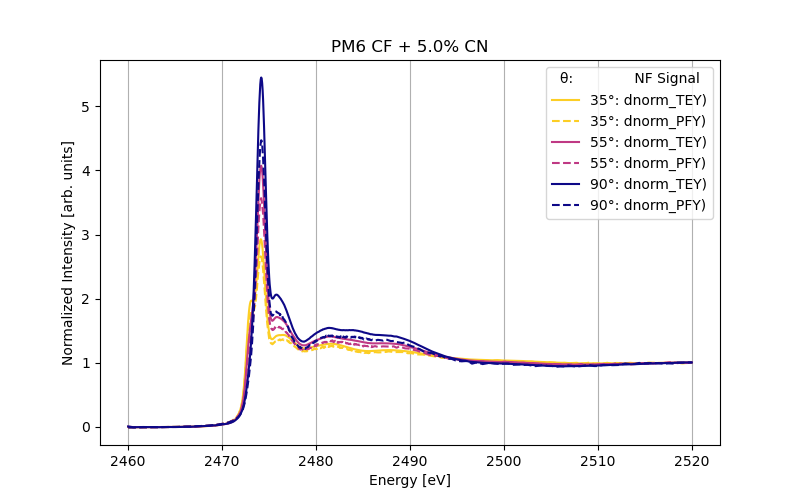

In [7]:
%matplotlib widget
plt.close('all')
# e_slice = slice(2470, 2485)
e_slice = slice(2460, 2520)
# e_slice = slice(None, None)

colors = plt.cm.plasma_r(np.linspace(0.1,1,3))

for sample_ID in ['Al_01', 'Al_02', 'Al_03', 'Al_04']:
    fig, ax = plt.subplots(figsize=(8,5))
    for color, theta in zip(colors, nf_DS.theta.data):
        # sel_DA = nf_DS['SampleDrain'].sel(sample_ID=sample_ID, theta=theta)
        # # sel_DA = nf_DS['ifluor'].sel(sample_ID=sample_ID, theta=theta)

        # sel_DA = sel_DA / nf_DS['i0'].sel(sample_ID=sample_ID, theta=theta)  # quick i0 normalization
        # sel_DA = sel_DA - sel_DA.sel(energy=slice(2461,2468)).mean()  # quick pre edge normalization
        # sel_DA = sel_DA / sel_DA.sel(energy=slice(2520,2550)).mean()  # quick post edge normalization
        
        # sel_DA.sel(energy=e_slice).plot.line(ax=ax, color=color, label=theta)
        # for signal in ['SampleDrain', 'ifluor']:
        for signal in ['dnorm_TEY', 'dnorm_PFY']:
            sel_DA = nf_DS[signal].sel(sample_ID=sample_ID, theta=theta)
    
            # sel_DA = sel_DA / nf_DS['i0'].sel(sample_ID=sample_ID, theta=theta)  # quick i0 normalization
            # sel_DA = sel_DA - sel_DA.sel(energy=slice(2461,2468)).mean()  # quick pre edge normalization
            # sel_DA = sel_DA / sel_DA.sel(energy=slice(2510,2530)).mean()  # quick post edge normalization

            linestyle = '-' if signal == 'dnorm_TEY' else '--'
            # mode = 'TEY' if signal == 'SampleDrain' else 'PFY'
            # suffix = 'film top ~20-70 nm' if signal == 'SampleDrain' else 'film bulk ~200 nm'
            # sel_DA.sel(energy=e_slice).plot.line(ax=ax, color=color, label=f'{theta}°: {mode} ({suffix})', linestyle=linestyle)
            sel_DA.sel(energy=e_slice).plot.line(ax=ax, color=color, label=f'{theta}°: {signal})', linestyle=linestyle)

    ax.legend(title='θ:              NF Signal')
    ax.set(xlabel='Energy [eV]', ylabel='Normalized Intensity [arb. units]')
    # ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.grid(visible=True, axis='x', which='both')
    ax.set_title(sn[sample_ID])

    # savePath = outPath.joinpath('sample_across_theta_v1')
    # savePath.mkdir(exist_ok=True)
    # fig.savefig(savePath.joinpath(f'{sample_ID}.png'), dpi=120, bbox_inches='tight')
    
    plt.show()

In [8]:
outPath

PosixPath('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/data_analysis/rsoxs_suite/local_data/MEX2_SKedge_NF')

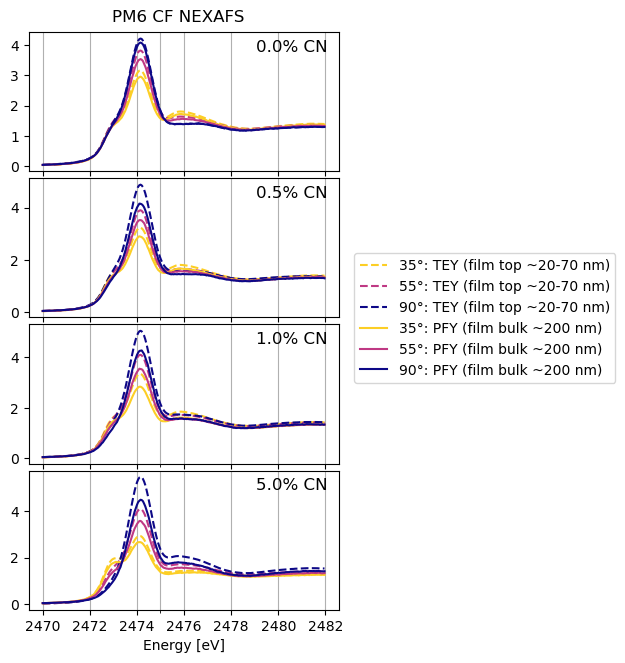

In [15]:
%matplotlib inline
plt.close('all')
e_slice = slice(2470, 2482)
# e_slice = slice(2468, 2495)
# e_slice = slice(2460, 2520)
# e_slice = slice(None, None)

colors = plt.cm.plasma_r(np.linspace(0.1,1,3))

fig, axs = plt.subplots(nrows=4, figsize=(4,7.5), sharex=True)
fig.subplots_adjust(hspace=0.05)

for ax, sample_ID in zip(axs, ['Al_01', 'Al_02', 'Al_03', 'Al_04']):
    # fig, ax = plt.subplots(figsize=(8,5))
    # for color, theta in zip(colors, nf_DS.theta.data):
    for signal in ['SampleDrain', 'ifluor']:
        # sel_DA = nf_DS['SampleDrain'].sel(sample_ID=sample_ID, theta=theta)
        # # sel_DA = nf_DS['ifluor'].sel(sample_ID=sample_ID, theta=theta)

        # sel_DA = sel_DA / nf_DS['i0'].sel(sample_ID=sample_ID, theta=theta)  # quick i0 normalization
        # sel_DA = sel_DA - sel_DA.sel(energy=slice(2461,2468)).mean()  # quick pre edge normalization
        # sel_DA = sel_DA / sel_DA.sel(energy=slice(2520,2550)).mean()  # quick post edge normalization
        
        # sel_DA.sel(energy=e_slice).plot.line(ax=ax, color=color, label=theta)
        # for signal in ['SampleDrain', 'ifluor']:
        # for signal in ['SampleDrain']:
        for color, theta in zip(colors, nf_DS.theta.data):
            sel_DA = nf_DS[signal].sel(sample_ID=sample_ID, theta=theta)
    
            sel_DA = sel_DA / nf_DS['i0'].sel(sample_ID=sample_ID, theta=theta)  # quick i0 normalization
            sel_DA = sel_DA - sel_DA.sel(energy=slice(2461,2468)).mean()  # quick pre edge normalization
            sel_DA = sel_DA / sel_DA.sel(energy=slice(2510,2530)).mean()  # quick post edge normalization

            linestyle = '--' if signal == 'SampleDrain' else '-'
            # linestyle = '--' 
            mode = 'TEY' if signal == 'SampleDrain' else 'PFY'
            suffix = 'film top ~20-70 nm' if signal == 'SampleDrain' else 'film bulk ~200 nm'
            sel_DA.sel(energy=e_slice).plot.line(ax=ax, color=color, label=f'{theta}°: {mode} ({suffix})', linestyle=linestyle)

    # ax.legend(title='θ:              NF Signal')
    ax.set(xlabel=None, ylabel=None)
    # ax.set(xlabel='Energy [eV]', ylabel='Normalized Intensity [arb. units]')
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    # ax.xaxis.set_major_locator(MultipleLocator(4))
    ax.grid(visible=True, axis='x', which='both')
    ax.set_title(None)
    ax.set_title(CN_val[sample_ID],x=0.85, y=0.8)

fig.suptitle('PM6 CF NEXAFS', y=0.91)
axs[-1].set(xlabel='Energy [eV]')
axs[2].legend(loc=(1.05,0.58))

savePath = outPath.joinpath('samples_across_theta_v2')
savePath.mkdir(exist_ok=True)
# fig.savefig(savePath.joinpath(f'{e_slice.start}-{e_slice.stop}_sampledrain.png'), dpi=120, bbox_inches='tight')
fig.savefig(savePath.joinpath(f'{e_slice.start}-{e_slice.stop}_both.png'), dpi=120, bbox_inches='tight')

plt.show()

### Theta across sample

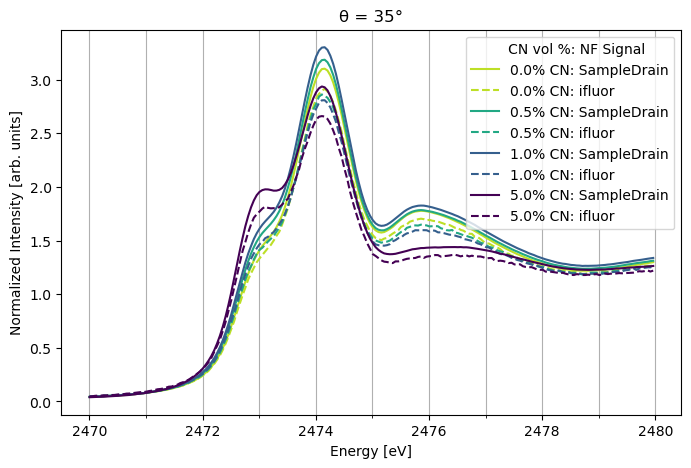

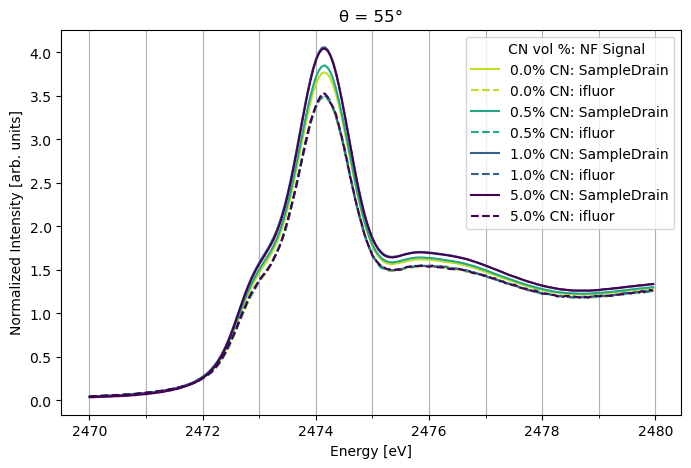

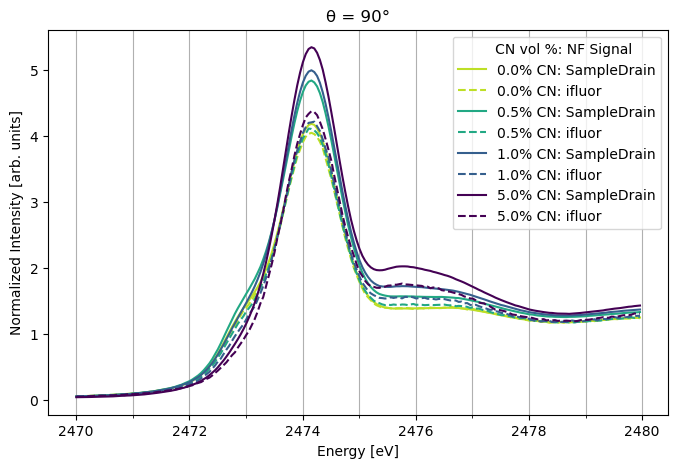

In [456]:
%matplotlib inline
plt.close('all')
e_slice = slice(2470, 2480)
# e_slice = slice(2460, 2510)
# e_slice = slice(None, None)

colors = plt.cm.viridis_r(np.linspace(0.1,1,4))

for theta in nf_DS.theta.data:
    fig, ax = plt.subplots(figsize=(8,5))
    for color, sample_ID in zip(colors, ['Al_01', 'Al_02', 'Al_03', 'Al_04']):
        for signal in ['SampleDrain', 'ifluor']:
        # sel_DA = nf_DS['SampleDrain'].sel(sample_ID=sample_ID, theta=theta)
        # sel_DA = nf_DS['ifluor'].sel(sample_ID=sample_ID, theta=theta)
            sel_DA = nf_DS[signal].sel(sample_ID=sample_ID, theta=theta)
    
            sel_DA = sel_DA / nf_DS['i0'].sel(sample_ID=sample_ID, theta=theta)  # quick i0 normalization
            sel_DA = sel_DA - sel_DA.sel(energy=slice(2461,2468)).mean()  # quick pre edge normalization
            sel_DA = sel_DA / sel_DA.sel(energy=slice(2520,2550)).mean()  # quick post edge normalization

            linestyle = '-' if signal == 'SampleDrain' else '--'
            sel_DA.sel(energy=e_slice).plot.line(ax=ax, color=color, label=f'{CN_val[sample_ID]}: {signal}', linestyle=linestyle)
            
    ax.legend(title='   CN vol %: NF Signal')
    ax.set(xlabel='Energy [eV]', ylabel='Normalized Intensity [arb. units]')
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.grid(visible=True, axis='x', which='both')
    ax.set_title(f'θ = {theta}°')
            
    # savePath = outPath.joinpath('theta_across_sample_v1')
    # savePath.mkdir(exist_ok=True)
    # fig.savefig(savePath.joinpath(f'{theta}_degree.png'), dpi=120, bbox_inches='tight')
    
plt.show()

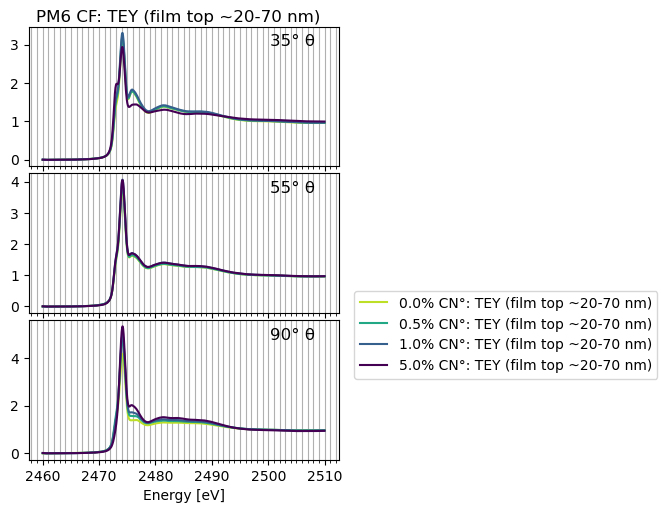

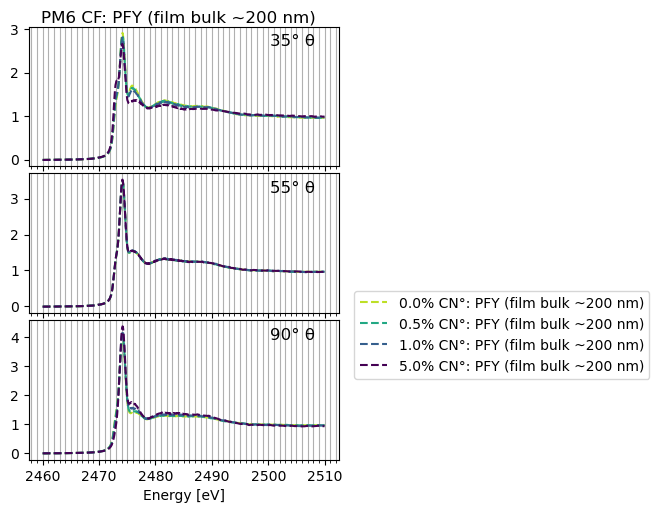

In [494]:
%matplotlib inline
plt.close('all')
# e_slice = slice(2470, 2480)
e_slice = slice(2460, 2510)
# e_slice = slice(None, None)

colors = plt.cm.viridis_r(np.linspace(0.1,1,4))


for signal in ['SampleDrain', 'ifluor']:
# for signal in ['ifluor']:
    fig, axs = plt.subplots(nrows=3, figsize=(4,5.625), sharex=True)
    fig.subplots_adjust(hspace=0.05)
    for ax, theta in zip(axs, nf_DS.theta.data):
        # fig, ax = plt.subplots(figsize=(8,5))
        for color, sample_ID in zip(colors, ['Al_01', 'Al_02', 'Al_03', 'Al_04']):
            sel_DA = nf_DS[signal].sel(sample_ID=sample_ID, theta=theta)
    
            sel_DA = sel_DA / nf_DS['i0'].sel(sample_ID=sample_ID, theta=theta)  # quick i0 normalization
            sel_DA = sel_DA - sel_DA.sel(energy=slice(2461,2468)).mean()  # quick pre edge normalization
            sel_DA = sel_DA / sel_DA.sel(energy=slice(2520,2550)).mean()  # quick post edge normalization

    #         linestyle = '-' if signal == 'SampleDrain' else '--'
    #         sel_DA.sel(energy=e_slice).plot.line(ax=ax, color=color, label=f'{CN_val[sample_ID]}: {signal}', linestyle=linestyle)
            
    # ax.legend(title='   CN vol %: NF Signal')
    # ax.set(xlabel='Energy [eV]', ylabel='Normalized Intensity [arb. units]')
    # ax.xaxis.set_minor_locator(MultipleLocator(1))
    # ax.grid(visible=True, axis='x', which='both')
    # ax.set_title(f'θ = {theta}°')
            
            linestyle = '-' if signal == 'SampleDrain' else '--'
            mode = 'TEY' if signal == 'SampleDrain' else 'PFY'
            suffix = 'film top ~20-70 nm' if signal == 'SampleDrain' else 'film bulk ~200 nm'
            sel_DA.sel(energy=e_slice).plot.line(ax=ax, color=color, label=f'{CN_val[sample_ID]}°: {mode} ({suffix})', linestyle=linestyle)

        # ax.legend(title='θ:              NF Signal')
        ax.set(xlabel=None, ylabel=None)
        # ax.set(xlabel='Energy [eV]', ylabel='Normalized Intensity [arb. units]')
        ax.xaxis.set_minor_locator(MultipleLocator(1))
        # ax.xaxis.set_major_locator(MultipleLocator(4))
        ax.grid(visible=True, axis='x', which='both')
        ax.set_title(None)
        ax.set_title(f'{theta}° θ',x=0.85, y=0.8)

    fig.suptitle(f'PM6 CF: {mode} ({suffix})', y=0.91)
    axs[-1].set(xlabel='Energy [eV]')
    axs[2].legend(loc=(1.05,0.58))
    
    # savePath = outPath.joinpath('thetas_across_sample_v1')
    # savePath.mkdir(exist_ok=True)
    # fig.savefig(savePath.joinpath(f'{mode}_{e_slice.start}-{e_slice.stop}.png'), dpi=120, bbox_inches='tight')
    
    plt.show()

### Difference spectra

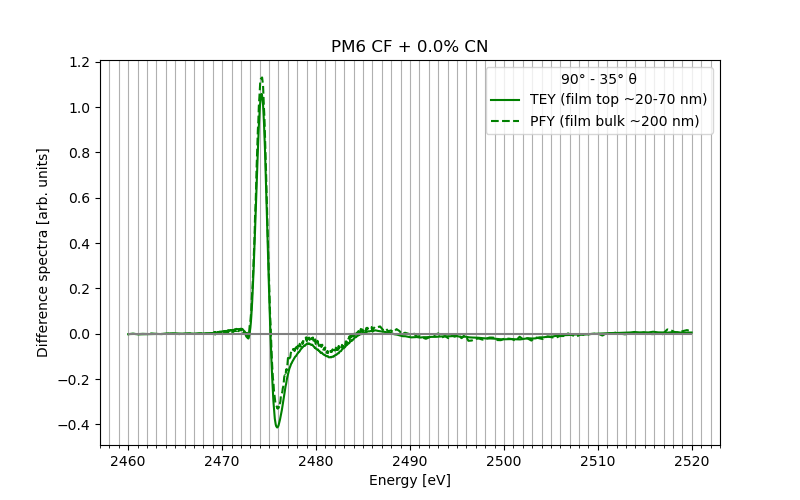

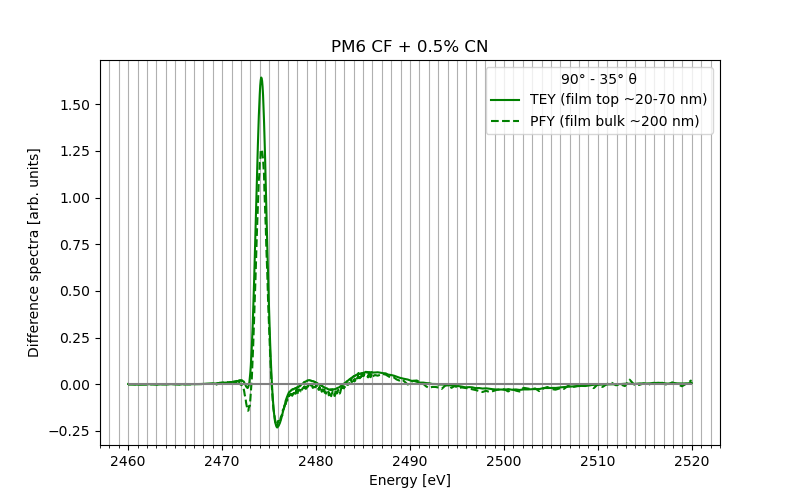

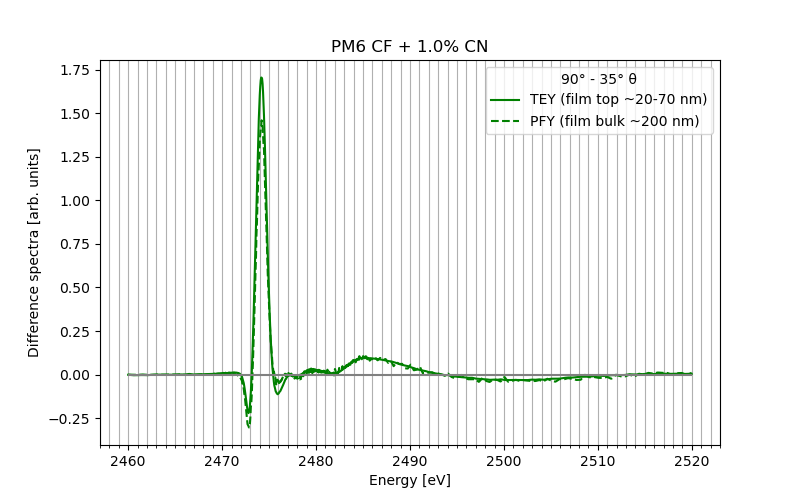

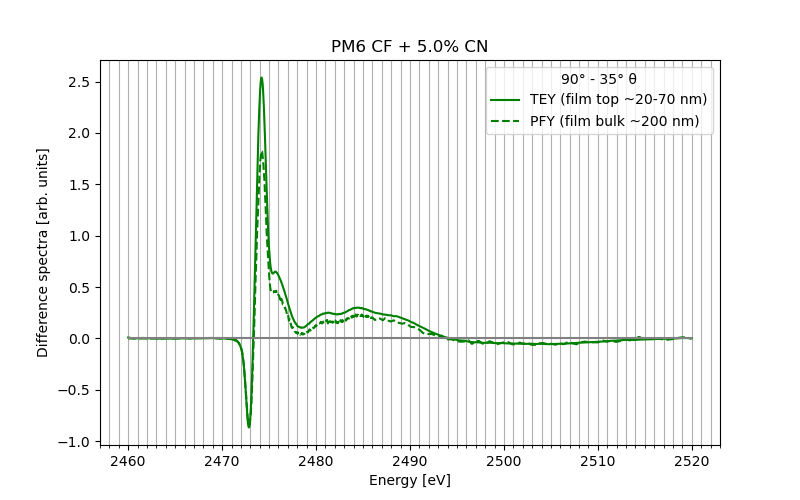

In [682]:
%matplotlib widget
plt.close('all')

# e_slice = slice(2468, 2495)
# e_slice = slice(2470, 2482)
e_slice = slice(2460, 2520)
# e_slice = slice(None, None)

colors = plt.cm.plasma_r(np.linspace(0.1,1,3))

for sample_ID in ['Al_01', 'Al_02', 'Al_03', 'Al_04']:
    fig, ax = plt.subplots(figsize=(8,5))
    # for color, theta in zip(colors, DS.theta.data):
    for signal in ['SampleDrain', 'ifluor']:
        sel_DA = nf_DS[signal].sel(sample_ID=sample_ID)

        sel_DA = sel_DA / nf_DS['i0'].sel(sample_ID=sample_ID)  # quick i0 normalization
        sel_DA = sel_DA - sel_DA.sel(energy=slice(2461,2468)).mean('energy')  # quick pre edge normalization
        sel_DA = sel_DA / sel_DA.sel(energy=slice(2510,2530)).mean('energy')  # quick post edge normalization

        diff_DA = sel_DA.sel(theta=90) - sel_DA.sel(theta=35)

        linestyle = '-' if signal == 'SampleDrain' else '--'
        mode = 'TEY' if signal == 'SampleDrain' else 'PFY'
        suffix = 'film top ~20-70 nm' if signal == 'SampleDrain' else 'film bulk ~200 nm'
        diff_DA.sel(energy=e_slice).plot.line(ax=ax, color='g', label=f'{mode} ({suffix})', linestyle=linestyle)

    ax.legend(title='90° - 35° θ')
    ax.set(xlabel='Energy [eV]', ylabel='Difference spectra [arb. units]')
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.grid(visible=True, axis='x', which='both')
    ax.set_title(f'{sn[sample_ID]}')
    ax.hlines(0, e_slice.start, e_slice.stop, color='grey')

    # # savePath = outPath.joinpath('sample_across_theta_v1')
    # # savePath.mkdir(exist_ok=True)
    # # fig.savefig(savePath.joinpath(f'{sample_ID}.png'), dpi=120, bbox_inches='tight')
    
    plt.show()

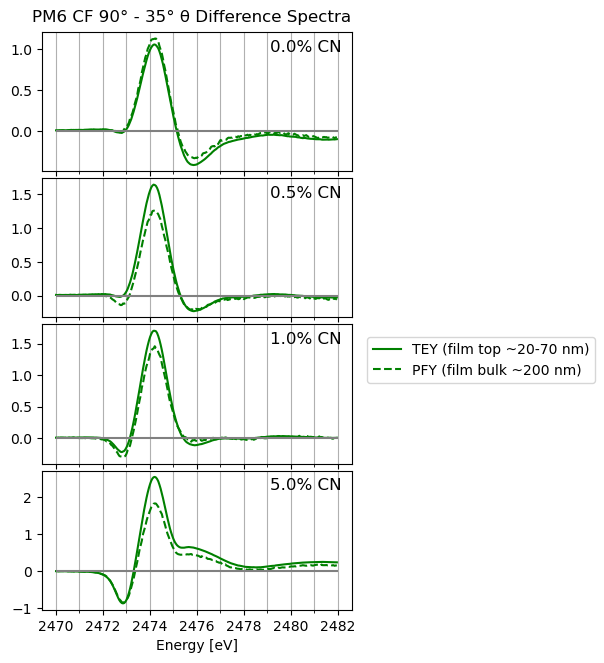

In [451]:
%matplotlib inline
plt.close('all')

e_slice = slice(2470, 2482)
# e_slice = slice(2468, 2495)
# e_slice = slice(2460, 2520)
# e_slice = slice(None, None)

# colors = plt.cm.plasma_r(np.linspace(0.1,1,3))

fig, axs = plt.subplots(nrows=4, figsize=(4,7.5), sharex=True)
fig.subplots_adjust(hspace=0.05)

for ax, sample_ID in zip(axs, ['Al_01', 'Al_02', 'Al_03', 'Al_04']):
    # fig, ax = plt.subplots(figsize=(8,5))
    # for color, theta in zip(colors, DS.theta.data):
    for signal in ['SampleDrain', 'ifluor']:
        sel_DA = nf_DS[signal].sel(sample_ID=sample_ID)

        sel_DA = sel_DA / nf_DS['i0'].sel(sample_ID=sample_ID)  # quick i0 normalization
        sel_DA = sel_DA - sel_DA.sel(energy=slice(2461,2468)).mean('energy')  # quick pre edge normalization
        sel_DA = sel_DA / sel_DA.sel(energy=slice(2510,2530)).mean('energy')  # quick post edge normalization

        diff_DA = sel_DA.sel(theta=90) - sel_DA.sel(theta=35)

        linestyle = '-' if signal == 'SampleDrain' else '--'
        mode = 'TEY' if signal == 'SampleDrain' else 'PFY'
        suffix = 'film top ~20-70 nm' if signal == 'SampleDrain' else 'film bulk ~200 nm'
        diff_DA.sel(energy=e_slice).plot.line(ax=ax, color='g', label=f'{mode} ({suffix})', linestyle=linestyle)

    # ax.legend(title='90° - 35° θ')
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.grid(visible=True, axis='x', which='both')
    ax.set_title(None)
    ax.set_title(CN_val[sample_ID],x=0.85, y=0.8)
    ax.hlines(0, e_slice.start, e_slice.stop, color='grey')

fig.suptitle('PM6 CF 90° - 35° θ Difference Spectra', y=0.91)
axs[-1].set(xlabel='Energy [eV]')
axs[2].legend(loc=(1.05,0.58))

savePath = outPath.joinpath('difference_spectra_v1')
savePath.mkdir(exist_ok=True)
fig.savefig(savePath.joinpath(f'{e_slice.start}-{e_slice.stop}.png'), dpi=120, bbox_inches='tight')

plt.show()

## Quick fitting

In [8]:
# Import relevant lmfit functions:
from lmfit.lineshapes import gaussian, step  # functions that return arrays based on defined function
from lmfit import Model, Parameters, minimize  # lmfit pieces to combose parameters and run minimization fit (can use equivalent Minimizer class instead of minimize)
from lmfit.model import save_modelresult, load_modelresult

In [9]:
display(nf_DS)

# for sample_ID in nf_DS['dnorm_PFY'].sample_ID.values:
#     nf_DS['dnorm_PFY'].sel(sample_ID=sample_ID).plot.line(hue='theta')
#     plt.show()

<xarray.Dataset>
Dimensions:       (sample_ID: 4, theta: 3, energy: 2000)
Coordinates:
  * sample_ID     (sample_ID) <U5 'Al_01' 'Al_02' 'Al_03' 'Al_04'
  * theta         (theta) int64 35 55 90
  * energy        (energy) float64 2.46e+03 2.46e+03 ... 2.56e+03 2.56e+03
Data variables:
    bragg         (energy, sample_ID, theta) float64 53.4 53.4 ... 50.48 50.48
    count_time    (energy, sample_ID, theta) float64 1.0 1.0 1.0 ... 1.0 1.0 1.0
    BIM           (energy, sample_ID, theta) float64 3.018 3.013 ... 3.105 3.103
    i0            (energy, sample_ID, theta) float64 1.706 1.711 ... 1.883 1.891
    SampleDrain   (energy, sample_ID, theta) float64 0.4575 0.6401 ... 1.71 1.39
    roi_avg_kCPS  (energy, sample_ID, theta) float64 0.1948 0.153 ... 6.94 5.592
    ifluor        (energy, sample_ID, theta) float64 198.4 155.6 ... 5.641e+03
    mufluor       (energy, sample_ID, theta) float64 116.3 90.92 ... 2.983e+03
    dnorm_TEY     (energy, sample_ID, theta) float64 -0.00776 ... 0.9666
    dnorm_PFY     (energy, sample_ID, theta) float64 -0.008022 ... 0.9863

In [15]:
# Define a total function for the curves to be included in the data:

# Total function in this case will have: 1 linear background, 1 exponential decay background and 6 pseudo-voigt peaks:
# Peaks: lamella, backbone, 0p9, 1p2, alkyl, and pipi
def total_func(x,
               amp_step, cen_step, sigma_step,
               amp_1, cen_1, sigma_1,
               amp_2, cen_2, sigma_2,
               amp_3, cen_3, sigma_3,
               amp_4, cen_4, sigma_4
               # amp_5, cen_5, sigma_5
              ):

    return (
            step(x, amplitude=amp_step, center=cen_step, sigma=sigma_step, form='erf') + 
            gaussian(x, amp_1, cen_1, sigma_1) +
            gaussian(x, amp_2, cen_2, sigma_2) +
            gaussian(x, amp_3, cen_3, sigma_3) +
            gaussian(x, amp_4, cen_4, sigma_4) 
            # gaussian(x, amp_5, cen_5, sigma_5)
    )


# Initialize function as an lmfit model object to fit directly
model = Model(total_func, independent_vars=['x'])

# Functions to plot inidividual fit components from parameters later on:
def gaussian_peak(pars, x, peakname):
    amp, cen, sigma = pars[f'amp_{peakname}'].value, pars[f'cen_{peakname}'].value, pars[f'sigma_{peakname}'].value
    return gaussian(x, amp, cen, sigma)

def step_fxn(pars, x):
    return step(x, amplitude=pars['amp_step'], center=pars['cen_step'], sigma=pars['sigma_step'], form='erf')

In [34]:
# Otherwise, initialize new parameters 
params = Parameters() 

params.add(f'amp_1',   value=1.5,     min=0,       max=8,      vary=True)
# params.add(f'cen_1',   value=2473.1,  min=2472.9,  max=2473.3, vary=False)
params.add(f'cen_1',   value=2473.05,  min=2472.7,  max=2473.3, vary=False)
params.add(f'sigma_1', value=0.45,     min=  0.3,  max=0.5,     vary=True)

params.add(f'amp_2',   value=5,       min=0,       max=10,     vary=True)
params.add(f'cen_2',   value=2474.15,  min=2474.1,  max=2474.3, vary=False)
params.add(f'sigma_2', value=0.45,     min=  0.4,  max=0.5,     vary=True)

params.add(f'amp_3',   value=3,      min=0,       max=8,      vary=True)
params.add(f'cen_3',   value=2475.7,  min=2475.6,  max=2476, vary=False)
params.add(f'sigma_3', value=1.2,       min=  1.15,  max=1.25,     vary=True)

params.add(f'amp_4',   value=2,      min=0,       max=8,      vary=True)
params.add(f'cen_4',   value=2477.85,  min=2477,  max=2478, vary=False)
params.add(f'sigma_4', value=1,       min=  0.95,  max=1.05,     vary=True)

# params.add(f'amp_5',   value=0,      min=0,       max=2,      vary=False)
# params.add(f'cen_5',   value=2481.15,  min=2481,  max=2482, vary=False)
# params.add(f'sigma_5', value=1,       min=  0.8,  max=1.8,     vary=True)

params.add(f'amp_step',   value=1,    min=0.9,  max=1, vary=False)
params.add(f'cen_step',   value=2480,    min=2478.5,  max=2481, vary=True)
params.add(f'sigma_step', value=0.2,       min=  0.1,  max=0.3,     vary=True)

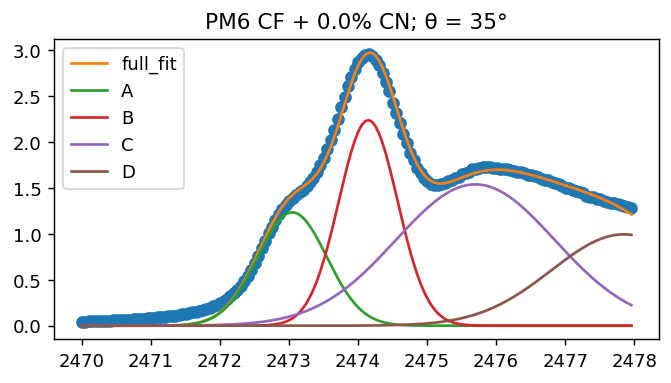

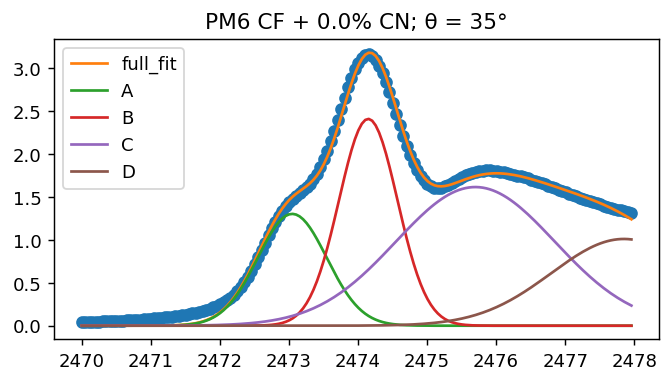

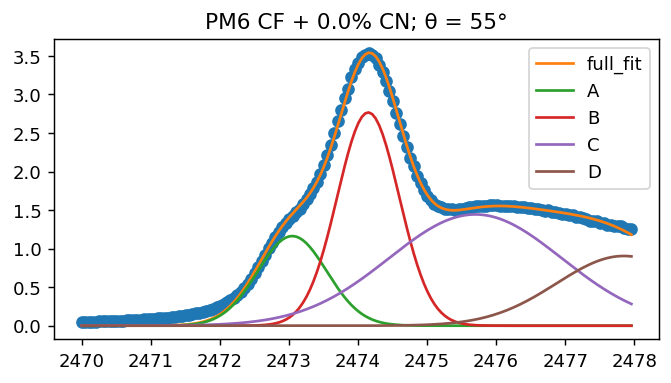

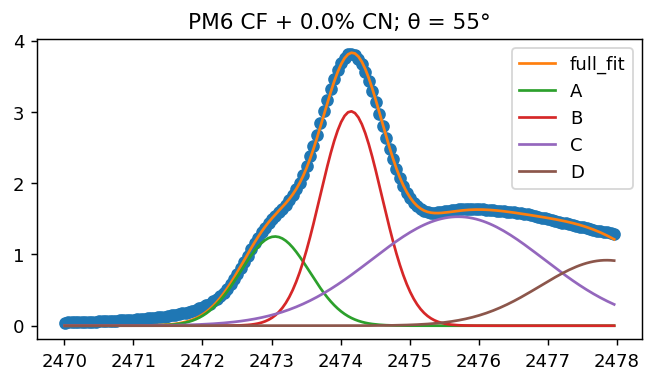

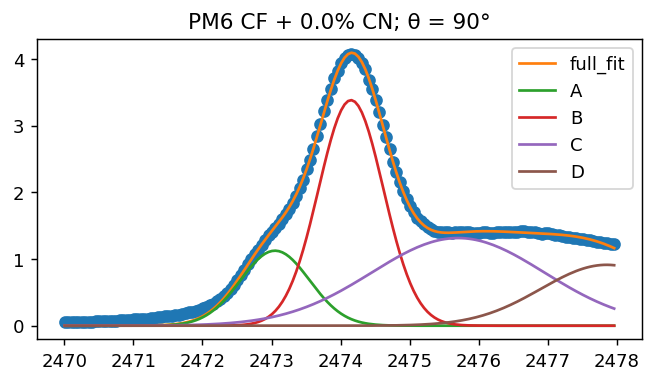

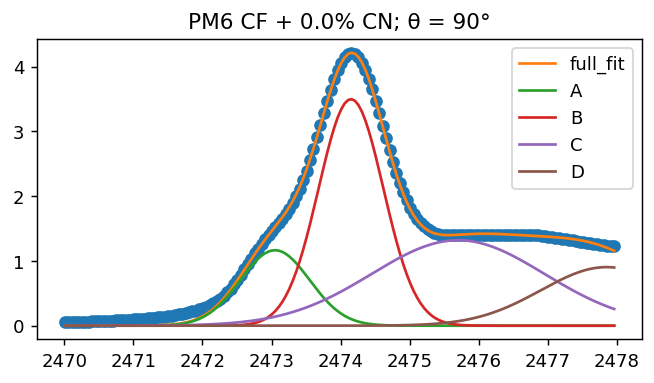

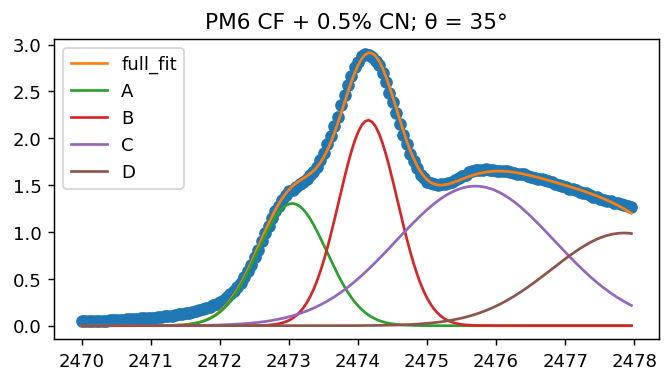

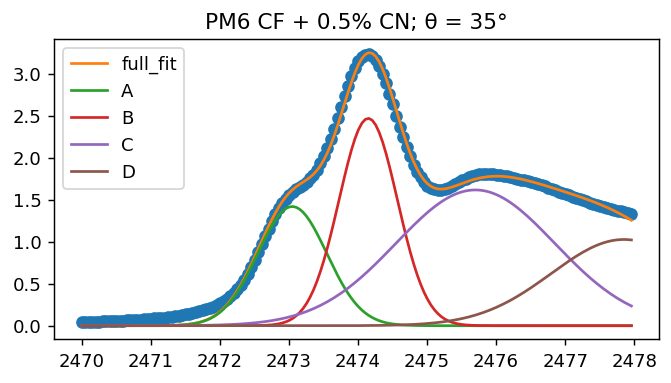

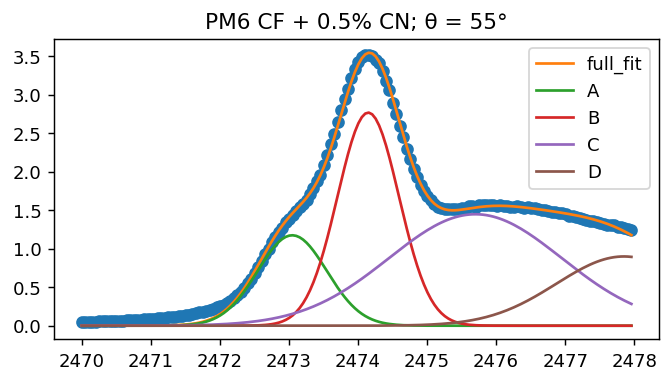

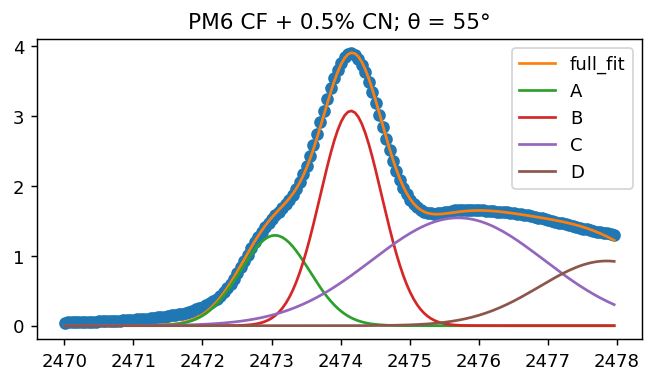

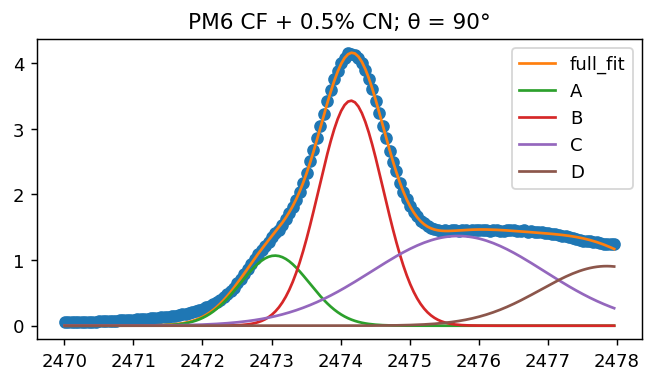

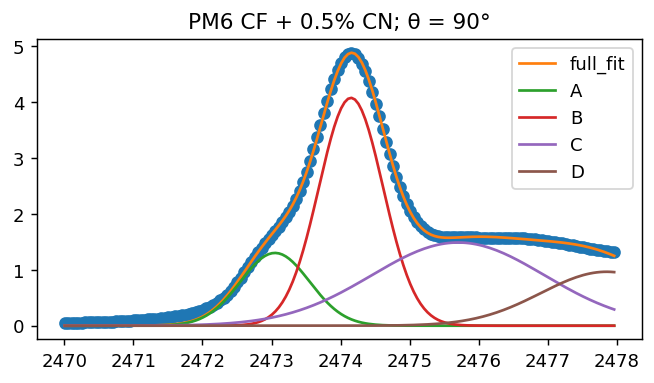

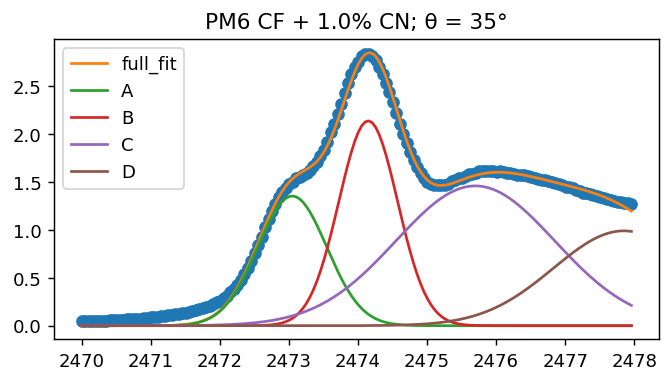

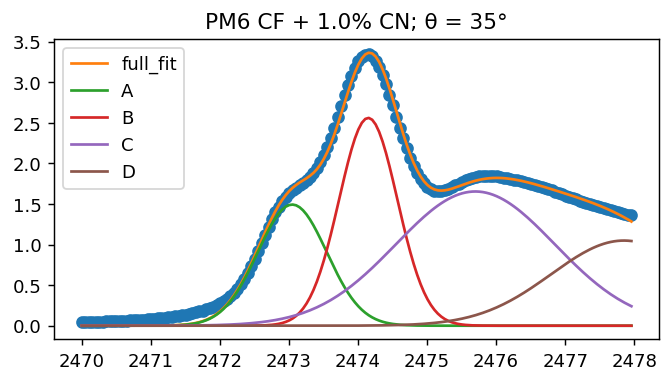

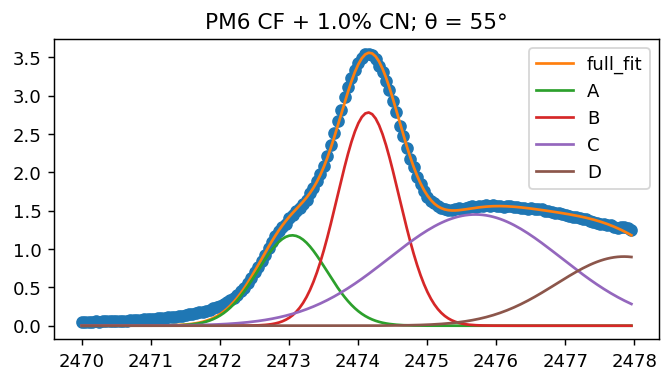

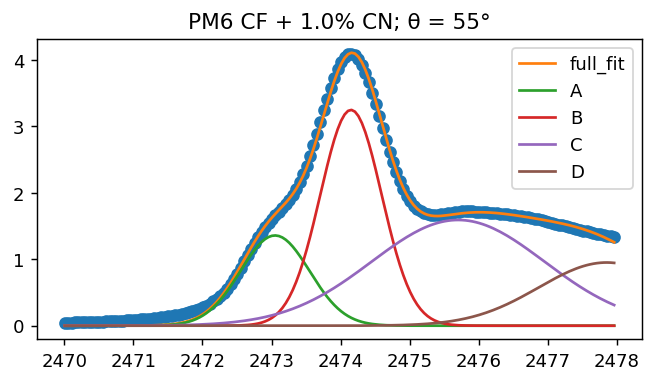

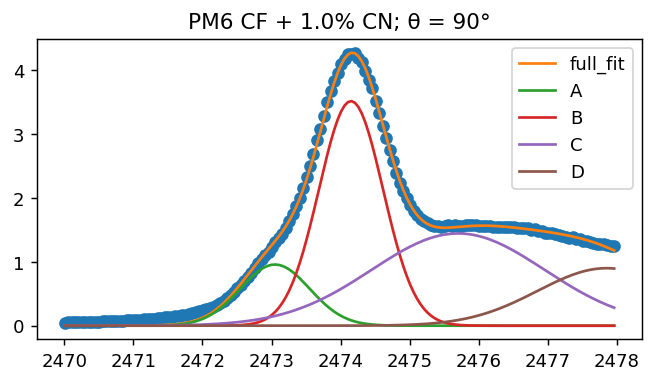

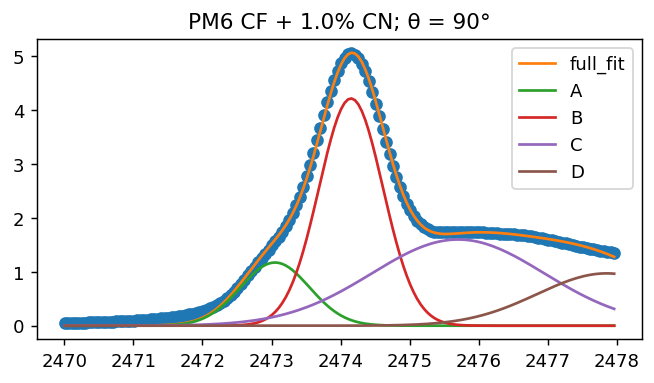

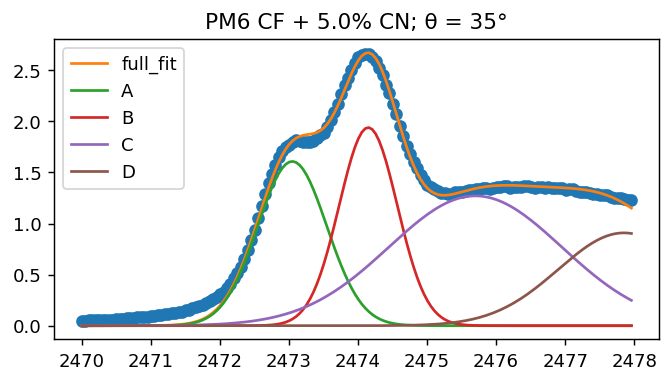

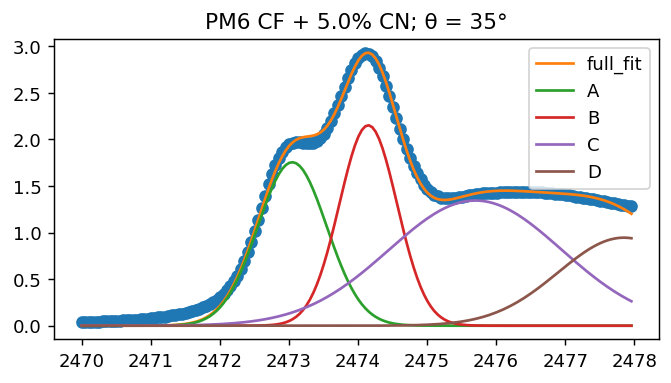

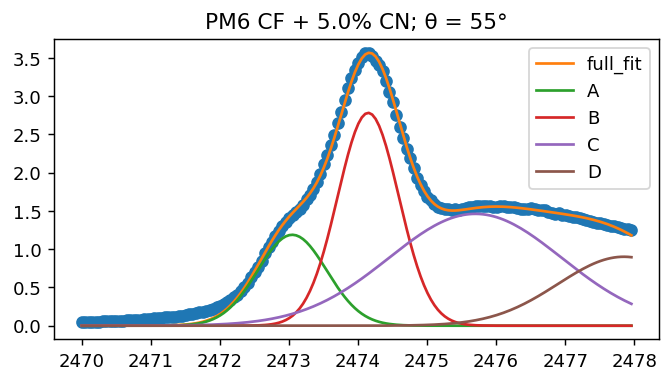

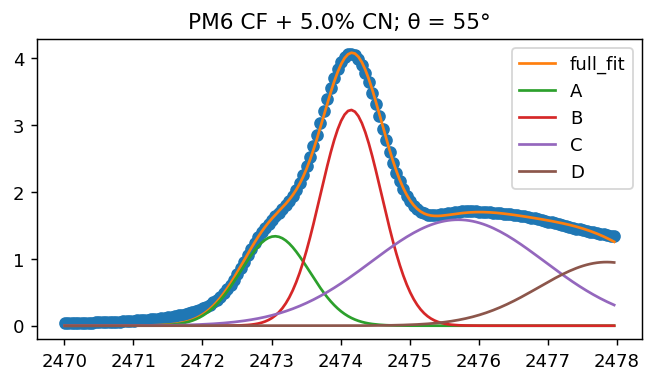

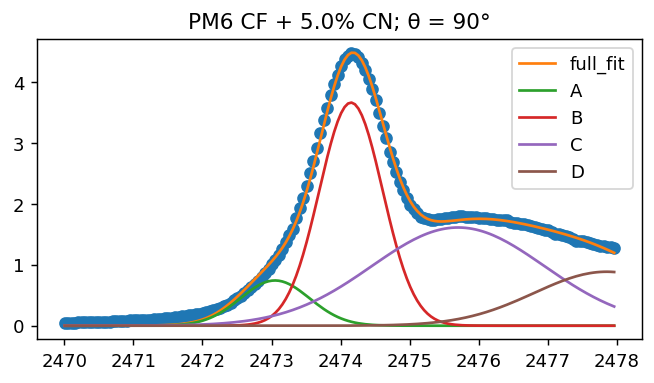

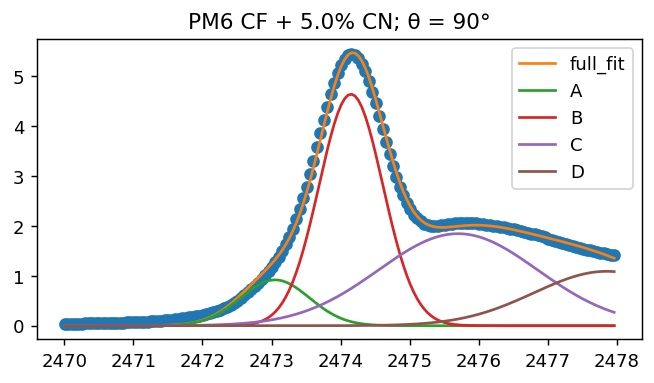

In [124]:
%matplotlib inline
plt.close('all')

e_slice = slice(2470,2478)

peak_area_DSs = []
for sample_ID in nf_DS.sample_ID.values[:]:
    for theta in nf_DS.theta.values[:]:
        for signal in ['dnorm_PFY', 'dnorm_TEY']:
            # sel_DA = nf_DS['dnorm_PFY'].sel(sample_ID='Al_01', theta=90, energy=slice(2470,2478))
            sel_DA = nf_DS[signal].sel(sample_ID=sample_ID, theta=theta, energy=e_slice)
            # sel_DA.plot.line()
            # plt.show()
            
            data = sel_DA.data
            x = sel_DA.energy.data
            
            out = model.fit(data, params, x=x)
    
            # Save lmfit model result:
            save_modelresult(out, outPath.joinpath('fits', f'{e_slice.start}-{e_slice.stop}-eV_{signal}_{sample_ID}_{theta}.json'))
    
            vd = out.params.valuesdict()
            peak_area_DS = xr.Dataset()
            
            peak_area_DS[f'{signal}_A'] = xr.DataArray(data=np.array(vd['amp_1']).reshape(1,1), dims=['theta', 'sample_ID'], coords = {'theta': [theta], 'sample_ID': [sample_ID]})
            peak_area_DS[f'{signal}_B'] = xr.DataArray(data=np.array(vd['amp_2']).reshape(1,1), dims=['theta', 'sample_ID'], coords = {'theta': [theta], 'sample_ID': [sample_ID]})
            peak_area_DS[f'{signal}_C'] = xr.DataArray(data=np.array(vd['amp_3']).reshape(1,1), dims=['theta', 'sample_ID'], coords = {'theta': [theta], 'sample_ID': [sample_ID]})
            peak_area_DS[f'{signal}_D'] = xr.DataArray(data=np.array(vd['amp_4']).reshape(1,1), dims=['theta', 'sample_ID'], coords = {'theta': [theta], 'sample_ID': [sample_ID]})
    
            peak_area_DSs.append(peak_area_DS)
            
            # Plot:
            fig, ax = plt.subplots(figsize=(6,3), dpi=130)
            # fig, (ax, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16,5), sharey=False)
            gauss1 = gaussian_peak(out.params, x, '1')
            gauss2 = gaussian_peak(out.params, x, '2')
            gauss3 = gaussian_peak(out.params, x, '3')
            gauss4 = gaussian_peak(out.params, x, '4')
            # gauss5 = gaussian_peak(out.params, x, '5')
            # step1 = step_fxn(out.params, x)
            
            ax.plot(x, data, 'o')
            
            ax.plot(x, out.best_fit, '-', label='full_fit')
            ax.plot(x, gauss1, label=f'A')  #  {np.round(vd['sigma_1'], 2)}')
            ax.plot(x, gauss2, label=f'B')  #  {np.round(vd['sigma_2'], 2)}')
            ax.plot(x, gauss3, label=f'C')  # {np.round(vd['sigma_3'], 2)}')
            ax.plot(x, gauss4, label=f'D')  # {np.round(vd['sigma_4'], 2)}')
            # ax.plot(x, gauss5, label=f'etc')
            # ax.plot(x, step1, label=f'step')
    
            ax.set_title(f'{sn[sample_ID]}; θ = {theta}°')
            ax.legend()

            savePath = outPath.joinpath('plots/peak_fits_v3')
            savePath.mkdir(exist_ok=True)
            fig.savefig(savePath.joinpath(f'{sample_ID}_{e_slice.start}-{e_slice.stop}-eV_{signal}_{theta}-th.png'), dpi=140, bbox_inches='tight')
            
            plt.show()

In [36]:
out

In [72]:
peak_areas_DS = xr.combine_by_coords(peak_area_DSs)
display(peak_areas_DS)

<xarray.Dataset>
Dimensions:      (theta: 3, sample_ID: 4)
Coordinates:
  * theta        (theta) int64 35 55 90
  * sample_ID    (sample_ID) <U5 'Al_01' 'Al_02' 'Al_03' 'Al_04'
Data variables:
    dnorm_PFY_A  (theta, sample_ID) float64 1.545 1.636 1.697 ... 1.201 0.9299
    dnorm_PFY_B  (theta, sample_ID) float64 2.385 2.337 2.281 ... 4.098 4.204
    dnorm_PFY_C  (theta, sample_ID) float64 4.43 4.294 4.207 ... 4.53 5.046
    dnorm_PFY_D  (theta, sample_ID) float64 2.615 2.604 2.531 ... 2.254 2.33
    dnorm_TEY_A  (theta, sample_ID) float64 1.631 1.778 1.87 ... 1.467 1.151
    dnorm_TEY_B  (theta, sample_ID) float64 2.556 2.615 2.71 ... 4.891 5.371
    dnorm_TEY_C  (theta, sample_ID) float64 4.652 4.659 4.766 ... 5.004 5.312
    dnorm_TEY_D  (theta, sample_ID) float64 2.657 2.701 2.76 ... 2.439 2.866

In [38]:
# peak_areas_DS['dnorm_PFY_C'] = peak_areas_DS['dnorm_PFY_C1'] + peak_areas_DS['dnorm_PFY_C2']
# peak_areas_DS['dnorm_TEY_C'] = peak_areas_DS['dnorm_TEY_C1'] + peak_areas_DS['dnorm_TEY_C2']

In [73]:
peak_areas_DS = peak_areas_DS.assign_coords({'cos_sq_theta': ('theta', np.cos(np.deg2rad(peak_areas_DS.theta.values))**2)})
# peak_areas_DS.swap_dims({'theta':'cos_sq_theta'})['C'].plot.line(hue='sample_ID')
# plt.show()

### Molecular tilt fitting on peak areas

Alpha: 52.55 ± 0.36 degrees
Const: 4.66 ± 0.03 (a.u.)
S = 0.0545 ± 0.0090
Alpha: 52.96 ± 1.10 degrees
Const: 5.03 ± 0.11 (a.u.)
S = 0.0444 ± 0.0277
Alpha: 50.03 ± 0.51 degrees
Const: 5.04 ± 0.05 (a.u.)
S = 0.1189 ± 0.0130
Alpha: 42.67 ± 0.17 degrees
Const: 5.03 ± 0.02 (a.u.)
S = 0.3108 ± 0.0045


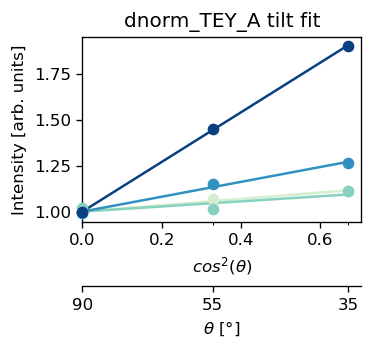

Alpha: 64.92 ± 0.11 degrees
Const: 10.02 ± 0.02 (a.u.)
S = -0.2304 ± 0.0022
Alpha: 68.26 ± 2.56 degrees
Const: 10.79 ± 0.40 (a.u.)
S = -0.2943 ± 0.0461
Alpha: 67.99 ± 1.76 degrees
Const: 11.22 ± 0.29 (a.u.)
S = -0.2893 ± 0.0320
Alpha: 76.12 ± 3.41 degrees
Const: 11.21 ± 0.36 (a.u.)
S = -0.4137 ± 0.0415


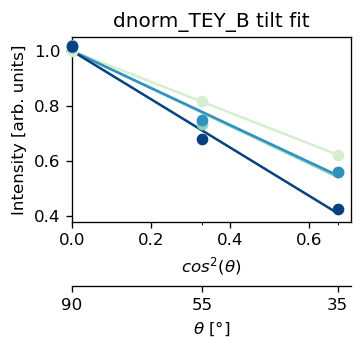

Alpha: 52.48 ± 2.02 degrees
Const: 13.58 ± 0.57 (a.u.)
S = 0.0563 ± 0.0511
Alpha: 54.74 ± 0.88 degrees
Const: 14.15 ± 0.25 (a.u.)
S = -0.0001 ± 0.0218
Alpha: 55.72 ± 0.48 degrees
Const: 14.76 ± 0.14 (a.u.)
S = -0.0242 ± 0.0117
Alpha: 59.50 ± 1.03 degrees
Const: 14.49 ± 0.28 (a.u.)
S = -0.1136 ± 0.0235


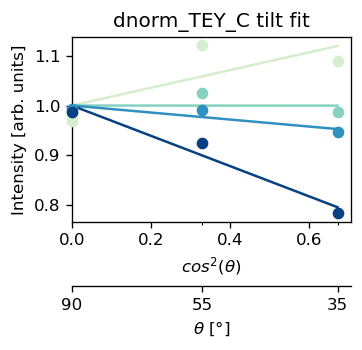

Alpha: 50.48 ± 1.81 degrees
Const: 7.02 ± 0.27 (a.u.)
S = 0.1073 ± 0.0465
Alpha: 51.39 ± 2.29 degrees
Const: 7.24 ± 0.35 (a.u.)
S = 0.0842 ± 0.0585
Alpha: 52.17 ± 2.31 degrees
Const: 7.54 ± 0.36 (a.u.)
S = 0.0642 ± 0.0586
Alpha: 59.89 ± 2.37 degrees
Const: 7.45 ± 0.33 (a.u.)
S = -0.1226 ± 0.0538


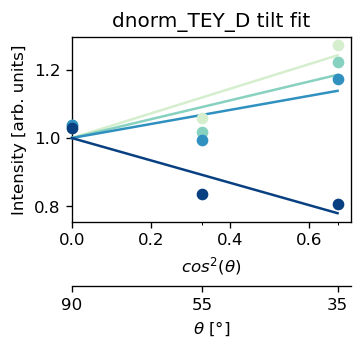

Alpha: 52.90 ± 0.28 degrees
Const: 4.41 ± 0.03 (a.u.)
S = 0.0458 ± 0.0071
Alpha: 50.80 ± 0.19 degrees
Const: 4.45 ± 0.02 (a.u.)
S = 0.0993 ± 0.0050
Alpha: 48.12 ± 0.49 degrees
Const: 4.37 ± 0.05 (a.u.)
S = 0.1686 ± 0.0127
Alpha: 40.60 ± 0.42 degrees
Const: 4.43 ± 0.04 (a.u.)
S = 0.3647 ± 0.0108


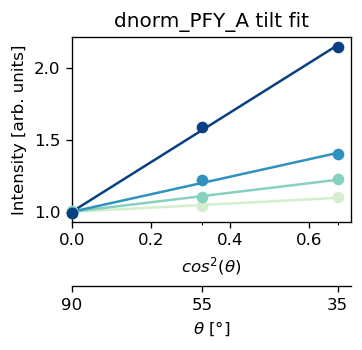

Alpha: 65.93 ± 0.87 degrees
Const: 9.47 ± 0.13 (a.u.)
S = -0.2505 ± 0.0171
Alpha: 66.63 ± 1.01 degrees
Const: 9.43 ± 0.15 (a.u.)
S = -0.2639 ± 0.0192
Alpha: 67.77 ± 1.02 degrees
Const: 9.49 ± 0.14 (a.u.)
S = -0.2853 ± 0.0186
Alpha: 71.20 ± 0.72 degrees
Const: 9.34 ± 0.08 (a.u.)
S = -0.3441 ± 0.0114


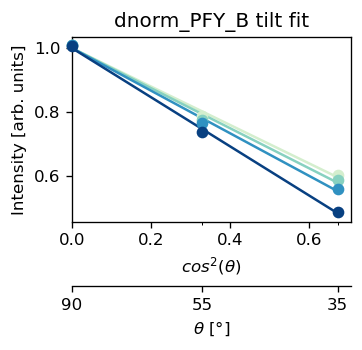

Alpha: 53.32 ± 1.32 degrees
Const: 13.07 ± 0.36 (a.u.)
S = 0.0351 ± 0.0332
Alpha: 54.71 ± 1.31 degrees
Const: 13.11 ± 0.35 (a.u.)
S = 0.0007 ± 0.0323
Alpha: 56.23 ± 0.91 degrees
Const: 13.28 ± 0.24 (a.u.)
S = -0.0365 ± 0.0220
Alpha: 59.64 ± 0.30 degrees
Const: 13.60 ± 0.08 (a.u.)
S = -0.1169 ± 0.0069


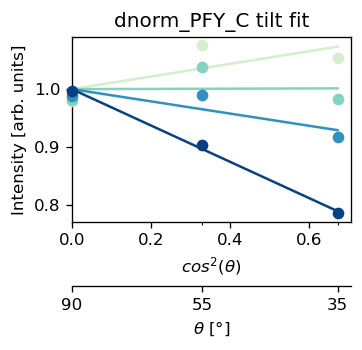

Alpha: 50.99 ± 1.70 degrees
Const: 7.00 ± 0.25 (a.u.)
S = 0.0943 ± 0.0436
Alpha: 50.97 ± 1.70 degrees
Const: 6.97 ± 0.25 (a.u.)
S = 0.0949 ± 0.0435
Alpha: 52.36 ± 1.80 degrees
Const: 6.99 ± 0.26 (a.u.)
S = 0.0595 ± 0.0456
Alpha: 56.25 ± 1.05 degrees
Const: 6.64 ± 0.14 (a.u.)
S = -0.0371 ± 0.0254


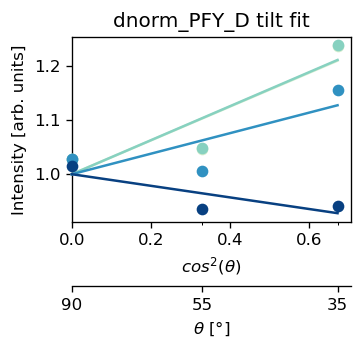

In [123]:
# Run Stöhr 9.16a tilt fit on energy region of NEXAFS
DS = peak_areas_DS.copy()

colors = plt.cm.GnBu(np.linspace(0.2,1,len(DS.sample_ID.values)))

tilts_DSs = []
tilt_errs_DSs = []
for peak in ['dnorm_TEY_A', 'dnorm_TEY_B', 'dnorm_TEY_C', 'dnorm_TEY_D',
             'dnorm_PFY_A', 'dnorm_PFY_B', 'dnorm_PFY_C', 'dnorm_PFY_D']:
    # fig, ax = plt.subplots(figsize=(6,4), dpi=120)
    fig, ax = plt.subplots(figsize=(3,2), dpi=120)
    for color, sample_ID in zip(colors, DS.sample_ID.values):
        DA = peak_areas_DS[peak].sel(sample_ID=sample_ID)
        pi_peak_areas = DA.data
        
        bnds = [(0, 90), (0, 50)]
        res = optimize.differential_evolution(
            nf.mse_line_tilt, bounds=bnds, args=(pi_peak_areas, DA.theta.values), tol=1e-6)
        
        alpha, const = res.x

        # ChatGPT: Use the differential evolution result as an initial guess
        x0 = res.x  # [alpha, const]
        
        # Wrap your model to return residuals
        def residuals(vars, pi_peak_areas, theta_list):
            alpha, const = vars
            return const * nf.i_nexafs(alpha, theta_list) - pi_peak_areas
        
        # Run least squares fit
        ls_res = optimize.least_squares(residuals, x0, args=(pi_peak_areas, DA.theta.values))
        
        # Get optimal values
        alpha, const = ls_res.x
        
        # Estimate standard deviation errors from the covariance matrix
        # Covariance = (J^T J)^-1 * residual variance
        J = ls_res.jac
        residual_var = np.sum(ls_res.fun**2) / (len(pi_peak_areas) - len(x0))
        cov = np.linalg.inv(J.T @ J) * residual_var
        errors = np.sqrt(np.diag(cov))
        
        alpha_err, const_err = errors
        
        print(f"Alpha: {alpha:.2f} ± {alpha_err:.2f} degrees")
        print(f"Const: {const:.2f} ± {const_err:.2f} (a.u.)")

        # Convert to radians once
        alpha_rad = np.deg2rad(alpha)
        alpha_err_rad = np.deg2rad(alpha_err)
        
        # Compute S
        fz = np.cos(alpha_rad)**2
        S = 0.5 * (3 * fz - 1)
        
        # Derivative of S w.r.t. alpha in degrees
        dS_dalpha = -3 * np.cos(alpha_rad) * np.sin(alpha_rad) * (np.pi / 180)
        
        # Error propagation
        S_err = np.abs(dS_dalpha) * alpha_err
        print(f"S = {S:.4f} ± {S_err:.4f}")
        
        # Append if peak of interest
        # if peak == 'trmsn_A':
        # Ss.append(S)
        # Ss_err.append(S_err)
        

        tilt_DS = xr.Dataset()
        tilt_err_DS = xr.Dataset()
        # tilt_DS[peak] = xr.DataArray(data=np.array([fz]), dims=['sample_ID'], coords={'sample_ID':[sample_ID]})
        tilt_DS[peak] = xr.DataArray(data=np.array([S]), dims=['sample_ID'], coords={'sample_ID':[sample_ID]})
        tilt_err_DS[peak] = xr.DataArray(data=np.array([S_err]), dims=['sample_ID'], coords={'sample_ID':[sample_ID]})
        tilts_DSs.append(tilt_DS)
        tilt_errs_DSs.append(tilt_err_DS)
        
        # Plot intensities from Stöhr 9.16a (scaled with fitted constant) as line
        # along with measured pi_peak_areas, x-axis is cos_sq_theta:
        # fig.suptitle(str(DA.sample_ID.values), y=1.03, fontsize=14)
        ax.plot(DA.cos_sq_theta.values[:], (const * nf.i_nexafs(alpha, DA.theta.values[:]))/(nf.i_nexafs(alpha, DA.theta.values[:])*const)[-1],
                marker='', color=color, label=f'{CN_val[sample_ID]}: S={np.round(S,2)} ($\\alpha$={np.round(alpha,1)}°)',
                clip_on=False, zorder=3)
        ax.plot(DA.cos_sq_theta.values[:], pi_peak_areas[:]/(nf.i_nexafs(alpha, DA.theta.values[:])*const)[-1], linestyle='', marker='o', color=color, clip_on=False, zorder=4)
        
    # ax.set(title=f'PM6 S K-edge NEXAFS peak {peak} tilt fit', xlabel=r'$cos^2(\theta)$', ylabel='Intensity [arb. units]')
    ax.set(title=f'{peak} tilt fit', xlabel=r'$cos^2(\theta)$', ylabel='Intensity [arb. units]')
    ax.set_xticks(DA.cos_sq_theta.values, minor=True)
    ax.set_xlim(left=0)
    # ax.legend()
    
    # Add secondary axis showing theta values:
    def forward(x):
        return np.arccos(np.sqrt(x)) * 180 / np.pi
    
    def inverse(x):
        return np.cos(x * np.pi / 180)**2
    
    # ax2 = ax.secondary_xaxis(-0.18, functions=(forward, inverse))
    ax2 = ax.secondary_xaxis(-0.35, functions=(forward, inverse))
    ax2.set(xlabel=r'$\theta$ [°]')
    ax2.set_xticks(DA.theta.values)
        
    savePath = outPath.joinpath('plots/tilt_fits_v3')
    savePath.mkdir(exist_ok=True)
    fig.savefig(savePath.joinpath(f'{peak}.png'), dpi=140, bbox_inches='tight')
        
    plt.show()
    plt.close('all')

In [129]:
tilts_DS = xr.combine_by_coords(tilts_DSs)
tilts_DS = tilts_DS.drop_vars(['dnorm_PFY_D', 'dnorm_TEY_D'])
# tilts_DS = tilts_DS.drop_vars(['dnorm_PFY_C', 'dnorm_TEY_C'])
tilts_DS 

<xarray.Dataset>
Dimensions:      (sample_ID: 4)
Coordinates:
  * sample_ID    (sample_ID) <U5 'Al_01' 'Al_02' 'Al_03' 'Al_04'
Data variables:
    dnorm_PFY_A  (sample_ID) float64 0.04583 0.09927 0.1686 0.3647
    dnorm_PFY_B  (sample_ID) float64 -0.2505 -0.2639 -0.2853 -0.3441
    dnorm_PFY_C  (sample_ID) float64 0.03513 0.0006679 -0.03646 -0.1169
    dnorm_TEY_A  (sample_ID) float64 0.05451 0.04436 0.1189 0.3108
    dnorm_TEY_B  (sample_ID) float64 -0.2304 -0.2943 -0.2893 -0.4137
    dnorm_TEY_C  (sample_ID) float64 0.05634 -0.0001236 -0.02418 -0.1136

In [130]:
tilt_errs_DS = xr.combine_by_coords(tilt_errs_DSs)
tilt_errs_DS = tilt_errs_DS.drop_vars(['dnorm_PFY_D', 'dnorm_TEY_D'])
# tilt_errs_DS = tilt_errs_DS.drop_vars(['dnorm_PFY_C', 'dnorm_TEY_C'])
tilt_errs_DS 

<xarray.Dataset>
Dimensions:      (sample_ID: 4)
Coordinates:
  * sample_ID    (sample_ID) <U5 'Al_01' 'Al_02' 'Al_03' 'Al_04'
Data variables:
    dnorm_PFY_A  (sample_ID) float64 0.007079 0.00497 0.0127 0.01077
    dnorm_PFY_B  (sample_ID) float64 0.01705 0.01922 0.01863 0.01143
    dnorm_PFY_C  (sample_ID) float64 0.0332 0.03234 0.02205 0.006853
    dnorm_TEY_A  (sample_ID) float64 0.009012 0.02772 0.01302 0.004543
    dnorm_TEY_B  (sample_ID) float64 0.002151 0.04611 0.03195 0.04153
    dnorm_TEY_C  (sample_ID) float64 0.05112 0.02182 0.01171 0.02351

In [131]:
# Add secondary y axis showing fz values:
def fz(S):
    return (2*S + 1) / 3

def S(fz):
    return (1/2) * (3*fz - 1)

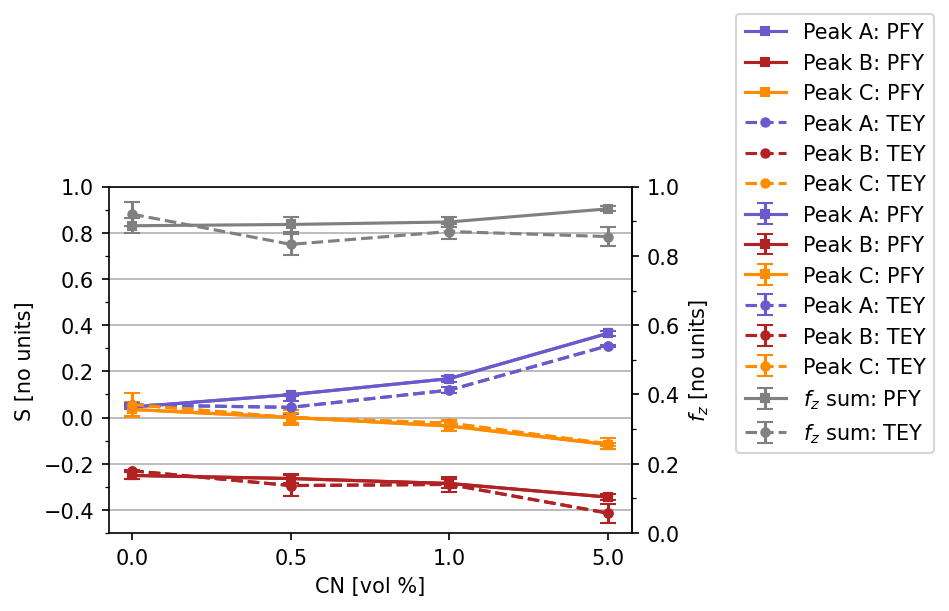

In [132]:
colors_dict = {
    'A': 'slateblue',
    'B': 'firebrick',
    'C': 'darkorange',
    'D': 'darkorange'
}


CN_vals = np.array(['0.0', '0.5', '1.0', '5.0'])

# To add fz sums
PFY_fz_sums_DA = fz(tilts_DS[['dnorm_PFY_A', 'dnorm_PFY_B', 'dnorm_PFY_C']]).to_array().sum('variable')
TEY_fz_sums_DA = fz(tilts_DS[['dnorm_TEY_A', 'dnorm_TEY_B', 'dnorm_TEY_C']]).to_array().sum('variable')

PFY_fz_errs_DA = fz(tilt_errs_DS[['dnorm_PFY_A', 'dnorm_PFY_B', 'dnorm_PFY_C']]).to_array().max('variable')
TEY_fz_errs_DA = fz(tilt_errs_DS[['dnorm_TEY_A', 'dnorm_TEY_B', 'dnorm_TEY_C']]).to_array().max('variable')

# PFY_fz_sums_DA = fz(tilts_DS[['dnorm_PFY_A', 'dnorm_PFY_B', 'dnorm_PFY_C1']]).to_array().sum('variable')
# TEY_fz_sums_DA = fz(tilts_DS[['dnorm_TEY_A', 'dnorm_TEY_B', 'dnorm_TEY_C1']]).to_array().sum('variable')

FY_TEY_arr = np.vstack((PFY_fz_sums_DA.data, TEY_fz_sums_DA)).T

means_arr = FY_TEY_arr.mean(axis=1)
stds_arr = FY_TEY_arr.std(axis=1)

fig, ax = plt.subplots(figsize=(4.5,3), dpi=150)
for DA, err_DA in zip(tilts_DS.data_vars.values(), tilt_errs_DS.data_vars.values()):
    _, signal, peak = DA.name.split('_')
    linestyle = '--' if signal == 'TEY' else '-'
    marker = 'o' if signal == 'TEY' else 's'
    ax.plot(CN_vals, DA.data, label=f'Peak {peak}: {signal}', color=colors_dict[peak], linestyle=linestyle, marker=marker, markersize=4)
    ax.errorbar(CN_vals, DA.data, yerr=err_DA.data, label=f'Peak {peak}: {signal}', color=colors_dict[peak], linestyle=linestyle, marker=marker, markersize=4, capsize=4)

# ax.plot(CN_vals, S(PFY_fz_sums_DA.data), label='$f_z$ sum: PFY', linestyle='-', marker='s', color='grey', markersize=4)
# ax.plot(CN_vals, S(TEY_fz_sums_DA.data), label='$f_z$ sum: TEY', linestyle='--', marker='o', color='grey', markersize=4)
ax.errorbar(CN_vals, S(PFY_fz_sums_DA.data), yerr=S(PFY_fz_errs_DA.data), label='$f_z$ sum: PFY', linestyle='-', marker='s', color='grey', markersize=4, capsize=4)
ax.errorbar(CN_vals, S(TEY_fz_sums_DA.data), yerr=S(TEY_fz_errs_DA.data), label='$f_z$ sum: TEY', linestyle='--', marker='o', color='grey', markersize=4, capsize=4)

ax.grid(visible=True, axis='y', which='major')
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
# ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.set(ylabel='S [no units]', xlabel='CN [vol %]')
# ax.set_title('PM6 S K-edge NEXAFS S parameter fit results')
ax.set_ylim(bottom=-0.5, top=1)
# ax.set_ylim(bottom=0, top=0.6)
ax.legend(loc=(1.2,0.23))

# Add secondary y axis showing fz values:
def fz(S):
    return (2*S + 1) / 3

def S(fz):
    return (1/2) * (3*fz - 1)

ax2 = ax.secondary_yaxis('right', functions=(fz, S))
ax2.yaxis.set_minor_locator(MultipleLocator(0.1))
ax2.set_ylabel('$f_z$ [no units]')

# savePath = outPath.joinpath('plots/tilt_fits_v3')
# savePath.mkdir(exist_ok=True)
# fig.savefig(savePath.joinpath(f'S_summary_plot_w_fz.png'), dpi=140, bbox_inches='tight')

plt.show()

In [26]:
tilts_DS

<xarray.Dataset>
Dimensions:      (sample_ID: 4)
Coordinates:
  * sample_ID    (sample_ID) <U5 'Al_01' 'Al_02' 'Al_03' 'Al_04'
Data variables:
    dnorm_PFY_A  (sample_ID) float64 0.05235 0.1038 0.1674 0.3357
    dnorm_PFY_B  (sample_ID) float64 -0.2733 -0.2906 -0.3094 -0.3934
    dnorm_PFY_C  (sample_ID) float64 0.05058 0.02835 -0.004754 -0.07525
    dnorm_TEY_A  (sample_ID) float64 0.06115 0.04886 0.1178 0.3042
    dnorm_TEY_B  (sample_ID) float64 -0.2519 -0.3145 -0.3086 -0.4432
    dnorm_TEY_C  (sample_ID) float64 0.06858 0.02367 0.003028 -0.1138

In [119]:
fz(tilts_DS)

<xarray.Dataset>
Dimensions:      (sample_ID: 4)
Coordinates:
  * sample_ID    (sample_ID) <U5 'Al_01' 'Al_02' 'Al_03' 'Al_04'
Data variables:
    dnorm_PFY_A  (sample_ID) float64 0.3682 0.4026 0.4449 0.5572
    dnorm_PFY_B  (sample_ID) float64 0.1511 0.1396 0.1271 0.07105
    dnorm_PFY_C  (sample_ID) float64 0.3671 0.3522 0.3302 0.2832
    dnorm_TEY_A  (sample_ID) float64 0.3741 0.3659 0.4119 0.5361
    dnorm_TEY_B  (sample_ID) float64 0.1654 0.1237 0.1276 0.03785
    dnorm_TEY_C  (sample_ID) float64 0.3791 0.3491 0.3353 0.2575

In [148]:
PFY_fz_sums_DA = fz(tilts_DS[['dnorm_PFY_A', 'dnorm_PFY_B', 'dnorm_PFY_C']]).to_array().sum('variable')
TEY_fz_sums_DA = fz(tilts_DS[['dnorm_TEY_A', 'dnorm_TEY_B', 'dnorm_TEY_C']]).to_array().sum('variable')

FY_TEY_arr = np.vstack((PFY_fz_sums_DA.data, TEY_fz_sums_DA)).T

display(FY_TEY_arr.mean(axis=1))
display(FY_TEY_arr.std(axis=1))

array([0.90248251, 0.86656652, 0.88850962, 0.87141501])

array([0.01605409, 0.02784692, 0.01366908, 0.0399649 ])

In [127]:
PFY_fz_sums_DA = fz(tilts_DS[['dnorm_PFY_A', 'dnorm_PFY_B', 'dnorm_PFY_C']]).to_array().sum('variable')
PFY_fz_sums_DA

<xarray.DataArray (sample_ID: 4)>
array([0.88642841, 0.89441345, 0.90217871, 0.91137991])
Coordinates:
  * sample_ID  (sample_ID) <U5 'Al_01' 'Al_02' 'Al_03' 'Al_04'

In [128]:
TEY_fz_sums_DA = fz(tilts_DS[['dnorm_TEY_A', 'dnorm_TEY_B', 'dnorm_TEY_C']]).to_array().sum('variable')
TEY_fz_sums_DA

<xarray.DataArray (sample_ID: 4)>
array([0.9185366 , 0.8387196 , 0.87484054, 0.83145011])
Coordinates:
  * sample_ID  (sample_ID) <U5 'Al_01' 'Al_02' 'Al_03' 'Al_04'

In [142]:
FY_TEY_arr = np.vstack((PFY_fz_sums_DA.data, TEY_fz_sums_DA)).T

In [147]:
S(FY_TEY_arr.mean(axis=1))

array([0.85372376, 0.79984979, 0.83276444, 0.80712252])

In [146]:
FY_TEY_arr.std(axis=1)

array([0.01605409, 0.02784692, 0.01366908, 0.0399649 ])

# Older code for SST1 PEY NEXAFS: Apply pre and post edge correction

In [ ]:
# Apply pre and post-edge normalizations (more involved right now...):

for nexafs_type in ['pey', 'tey', 'fy_csi']:
    data_var = f'dnorm_{nexafs_type}'

    # # Carbon
    # pre_edge_energy_slice = slice(276, 280)  # carbon  
    # post_edge_energy_slice = slice(305, 320)

    # Nitrogen
    pre_edge_energy_slice = slice(390, 397.4)  # nitrogen
    post_edge_energy_slice = slice(415, None)  # nitrogen


    # First generate list of corrected spectra
    pre_corr_list = []
    full_corr_list = []
    for sample_name in DS.sample_name.values:
        for theta in DS.theta.values:
            # Linear fit for pre-edge region
            if nexafs_type == 'fy_csi':
                pre_edge_mean = float(DS[data_var].sel(sample_name=sample_name, theta=theta, 
                                                       energy=pre_edge_energy_slice).mean(dim="energy"))
                # display(pre_edge_mean)
                pre_corr_DA = (DS[data_var].sel(sample_name=sample_name, theta=theta)) - pre_edge_mean
            else:
                # coefficients = np.polyfit(DS.energy.where(DS.energy<pre_edge_energy, drop=True), 
                #                           (DS['dnorm_trmsn']).where(DS.energy<pre_edge_energy, drop=True).sel(sample_name=sample_name, theta=theta), 1)   
                coefficients = np.polyfit(DS.energy.sel(energy=pre_edge_energy_slice), 
                                          DS[data_var].sel(energy=pre_edge_energy_slice, sample_name=sample_name, theta=theta), 
                                          1)
                y_fit = np.polyval(coefficients, DS.energy)
                pre_corr_DA = (DS[data_var].sel(sample_name=sample_name, theta=theta)) - y_fit
                
            pre_corr_DA = pre_corr_DA.expand_dims({'sample_name': [pre_corr_DA.sample_name.data],
                                                   'theta': [pre_corr_DA.theta.data]})
            pre_corr_DA = pre_corr_DA.assign_coords({'sample_id': ('sample_name', [pre_corr_DA.sample_id.data])})     

            pre_corr_list.append(pre_corr_DA)

            # Post edge
            # post_edge_mean = corr_DA.where(DS.energy>post_edge_energy, drop=True).mean(dim="energy")
            post_edge_mean = pre_corr_DA.sel(energy=post_edge_energy_slice).mean(dim="energy")
            full_corr_DA = pre_corr_DA / np.abs(float(post_edge_mean))        

            full_corr_list.append(full_corr_DA)

    # Now reconstruct full dataarray and add to dataset created in prior cell
    corr_names = [f'pre_corr_{nexafs_type}', f'full_corr_{nexafs_type}']

    for i, corr_list in enumerate([pre_corr_list, full_corr_list]):
    # corr_names = ['pre_corr_trmsn']
    # for i, corr_list in enumerate([pre_corr_list]):
        # First group by sample_name
        grouped_by_sample = {}
        for corr_DA in corr_list:
            sample_name = corr_DA.sample_name.values[0]
            if sample_name not in grouped_by_sample:
                grouped_by_sample[sample_name] = []
            grouped_by_sample[sample_name].append(corr_DA)

        # Concatenate by theta for each sample_name
        concat_by_theta = {}
        for sample_name, group in grouped_by_sample.items():
            concat_by_theta[sample_name] = xr.concat(group, dim="theta")

        # Finally, concatenate the result along the sample_name dimension
        DS[corr_names[i]] = xr.concat(list(concat_by_theta.values()), dim="sample_name")
    
DS

In [ ]:
# DS = loaded_DS.copy()
edge = 'nitrogen'
nexafs_type = 'pey'

# energy_min = 387  # nitrogen
# energy_max = 419.5  # nitrogen

# energy_min = 275
# energy_max = 320

# energy_slice = slice(energy_min, energy_max)
energy_slice = slice(None, None)

# energy_slice = slice(250,350) # carbon
# energy_slice = slice(370, 440) # nitrogen
# energy_slice = slice(396, 405) # nitrogen

# Create the colormap
colors = plt.cm.plasma_r(np.linspace(0.15, 1, len(DS.theta)))
# colors = plt.cm.plasma(np.linspace(0, 0.85, len(DS.theta)))


for sample_name in tqdm(DS.sample_name.values):
    fig, axs = plt.subplots(2, 2)
    fig.set(size_inches=(9, 6), dpi=120, tight_layout=True)
    fig.suptitle(f'{nexafs_type} {edge}-edge NEXAFS: {sample_name}', fontsize=14)
    # fig.suptitle(f'Transmission {edge}-edge NEXAFS: {sample_name}', fontsize=14)
    # fig.suptitle(f'TEY {edge}-edge NEXAFS: {sample_name}', fontsize=14)

    for i, theta_val in enumerate(DS.theta.values):
        sliced_DS = DS.sel(energy=energy_slice, sample_name=sample_name, theta=theta_val)
        sliced_DS[f'raw_{nexafs_type}'].plot.line(ax=axs[0,0], color=colors[i], label=f'{int(theta_val)}°')
        sliced_DS[f'dnorm_{nexafs_type}'].plot.line(ax=axs[0,1], color=colors[i], label=f'{int(theta_val)}°')
        sliced_DS[f'pre_corr_{nexafs_type}'].plot.line(ax=axs[1,0], color=colors[i], label=f'{int(theta_val)}°')
        sliced_DS[f'full_corr_{nexafs_type}'].plot.line(ax=axs[1,1], color=colors[i], label=f'{int(theta_val)}°')
        # ((sliced_DS[f'full_corr_{nexafs_type}'] / float(DS[f'full_corr_{nexafs_type}'].sel(
        #                                           sample_name=sample_name, theta=theta_val, energy=slice(402,404)).mean('energy')))
        #  .plot.line(ax=axs[1,1], color=colors[i], label=f'{int(theta_val)}°'))
    
    axs[0,0].set(title='Raw beamstop diode current')
    axs[0,1].set(title='Double-norm correction')
    axs[1,0].set(title='Subtract pre-edge linear fit')
    axs[1,1].set(title='Divide post-edge mean')
    # axs[1,1].set(title='Divide post-edge mean & subtract SiN spectra')

    # Optionally, add legends
    axs[0,0].legend(title=r"$\theta$", loc='upper right')
    axs[0,1].legend(title=r"$\theta$", loc='upper right')
    axs[1,0].legend(title=r"$\theta$", loc='upper right')
    axs[1,1].legend(title=r"$\theta$", loc='upper right')
    
    # savePath = outPath.joinpath(f'nexafs_plots/nf_chamber_{nexafs_type}_{edge}_nexafs_all')
    # savePath.mkdir(exist_ok=True)
    # fig.savefig(savePath.joinpath(f'{sample_name}_energy{energy_slice.start}-{energy_slice.stop}.png'), dpi=120)
    # # fig.savefig(outPath.joinpath(f'nexafs_plots/nf_chamber_{nexafs_type}_{edge}_nexafs_all', f'{sample_name}_energy{energy_min}-{energy_max}.png'), dpi=120)

    plt.show()
    plt.close('all')

## Save / load zarr

In [ ]:
edge

In [ ]:
# Define chunk sizes as the full shape of each variable
# Need to do this if zarr/xarray is bugging out(?)
encoding = {var: {'chunks': DS[var].shape} for var in DS.variables}

plan_of_interest = f'nexafs_{edge}'
DS.to_zarr(zarrsPath.joinpath(f'PEY_{plan_of_interest}.zarr'), mode='w', encoding=encoding)

In [ ]:
zarrsPath

In [ ]:
loaded_DS = xr.open_zarr(zarrsPath.joinpath('PEY_nexafs_carbon.zarr'))
# loaded_DS = xr.open_zarr(zarrsPath.joinpath('PEY_nexafs_nitrogen.zarr'))

DS = loaded_DS.compute()
DS

## Plotting

### NEXAFS all

In [ ]:
nexafs_type = 'pey'
edge = 'nitrogen'
energy_slice = slice(None, None) 

# Create the colormap
colors = plt.cm.plasma_r(np.linspace(0.15, 1, len(DS.theta)))

for nexafs_type in ['pey', 'tey', 'fy_csi']:
    for sample_name in tqdm(DS.sample_name.values):
        fig, axs = plt.subplots(2, 2)
        fig.set(size_inches=(9, 6), dpi=120, tight_layout=True)
        fig.suptitle(f'{nexafs_type} {edge}-edge NEXAFS: {sample_name}', fontsize=14)

        for i, theta_val in enumerate(DS.theta.values):
            sliced_DS = DS.sel(energy=energy_slice, sample_name=sample_name, theta=theta_val)
            sliced_DS[f'raw_{nexafs_type}'].plot.line(ax=axs[0,0], color=colors[i], label=f'{int(theta_val)}°')
            sliced_DS[f'dnorm_{nexafs_type}'].plot.line(ax=axs[0,1], color=colors[i], label=f'{int(theta_val)}°')
            sliced_DS[f'pre_corr_{nexafs_type}'].plot.line(ax=axs[1,0], color=colors[i], label=f'{int(theta_val)}°')
            sliced_DS[f'full_corr_{nexafs_type}'].plot.line(ax=axs[1,1], color=colors[i], label=f'{int(theta_val)}°')

        axs[0,0].set(title='Raw beamstop diode current')
        axs[0,1].set(title='Double-norm diode correction')
        axs[1,0].set(title='Subtract pre-edge linear fit')
        axs[1,1].set(title='Divide by post-edge mean')

        # Optionally, add legends
        axs[0,0].legend(title=r"$\theta$")
        axs[0,1].legend(title=r"$\theta$")
        axs[1,0].legend(title=r"$\theta$")
        axs[1,1].legend(title=r"$\theta$")


        savePath = outPath.joinpath(f'nexafs_plots/nf_chamber_{nexafs_type}_{edge}_nexafs_all')
        savePath.mkdir(exist_ok=True)
        fig.savefig(savePath.joinpath(f'{sample_name}_energy{energy_slice.start}-{energy_slice.stop}.png'), dpi=120)

        # plt.show()
        plt.close('all')

### NEXAFS single data variable

In [ ]:
DS

In [ ]:
edge = 'carbon'

if edge == 'carbon':
    energy_slice = slice(282, 310)  # carbon
elif edge == 'nitrogen':
    energy_slice = slice(395, 405)  # nitrogen

for nexafs_type in ['pey', 'tey', 'fy_csi']:
    for sample_name in tqdm(DS.sample_name.values[:]):
        colors = plt.cm.plasma_r(np.linspace(0.15,1,len(DS.theta)))
        fig, ax = plt.subplots(figsize=(7,3.5), dpi=120, tight_layout=True)
        for i, theta_val in enumerate(DS.theta.values):
            (DS[f'full_corr_{nexafs_type}'].sel(sample_name=sample_name, theta=theta_val, energy=energy_slice)
                                           .plot.line(ax=ax, color=colors[i], label=f'{int(theta_val)}°'))

        fig.suptitle(f'{nexafs_type} {edge}-edge NEXAFS: {sample_name}', x=0.53)
        ax.set(title='Pre-edge linear fit subtracted & post-edge mean normalized', xlabel='X-ray Energy [eV]', ylabel='Normalized NEXAFS [arb. units]')
        ax.legend(title=r'$\theta$')

        savePath = outPath.joinpath(f'nexafs_plots/nf_chamber_{nexafs_type}_{edge}_nexafs_full_corr')
        savePath.mkdir(exist_ok=True)
        fig.savefig(savePath.joinpath(f'{sample_name}_energy{energy_slice.start}-{energy_slice.stop}.png'), dpi=120)

        # plt.show()
        plt.close('all')

### Molecular tilt fit

In [ ]:
# Run Stöhr 9.16a tilt fit on energy region of NEXAFS

# carbon
# edge = 'carbon'
# energy_slice = slice(282, 292)

# nitrogen
edge = 'nitrogen' 
energy_slice = slice(395, 405)


# for e_min, e_max in [(283.5, 285.3), (283.5, 285.5), (284, 286)]:  # carbon peak area bounds
for e_min, e_max in [(397.8, 399), (399, 400.2), (400.2, 402)]:  # nitrogen peak area bounds
    for nexafs_type in ['pey', 'tey', 'fy_csi']:
        for sample_name in tqdm(DS.sample_name.values[:], desc=f'{nexafs_type}: ({e_min}, {e_max})'):
            nf_DA = DS[f'full_corr_{nexafs_type}'].sel(sample_name=sample_name)

            pi_peak_areas = nf.int_area(e_min, e_max, nf_DA)

            bnds = [(0, 90), (0, 20)]
            res = optimize.differential_evolution(
                nf.mse_line_tilt, bounds=bnds, args=(pi_peak_areas, nf_DA.theta.values), tol=1e-6)

            alpha, const = res.x

            # Plot intensities from Stöhr 9.16a (scaled with fitted constant) as line
            # along with measured pi_peak_areas, x-axis is cos_sq_theta:
            fig, axs = plt.subplots(ncols=2, figsize=(10,4.5), dpi=120, tight_layout=True)
            fig.suptitle(str(nf_DA.sample_name.values), fontsize=14)
            axs[0].plot(nf_DA.cos_sq_theta.values[:], const * nf.i_nexafs(alpha, nf_DA.theta.values[:]),
                    marker='o', label=f'Stöhr 9.16a: ($\\alpha$={np.round(alpha,2)}, const={np.round(const,2)})',
                    clip_on=False, zorder=3)
            axs[0].plot(nf_DA.cos_sq_theta.values[:], pi_peak_areas[:], marker='o',
                    label=f'NEXAFS integrated areas', clip_on=False, zorder=4)
            axs[0].set(title='Peak fit', xlabel=r'$cos^2(\theta)$', ylabel='Intensity [arb. units]')
            axs[0].set_xticks(nf_DA.cos_sq_theta.values, minor=True)
            axs[0].set_xlim(left=0)
            axs[0].legend()

            # Add secondary axis showing theta values:
            def forward(x):
                return np.arccos(np.sqrt(x)) * 180 / np.pi

            def inverse(x):
                return np.cos(x * np.pi / 180)**2

            ax2 = axs[0].secondary_xaxis(-0.23, functions=(forward, inverse))
            ax2.set(xlabel=r'$\theta$ [$\degree$]')
            ax2.set_xticks(nf_DA.theta.values)


            colors = plt.cm.plasma_r(np.linspace(0.15,1,len(nf_DA.theta)))
            for i, theta_val in enumerate(nf_DA.theta.values):
                (nf_DA.sel(theta=theta_val, energy=energy_slice)
                       .plot.line(ax=axs[1], color=colors[i], label=f'{int(theta_val)}°'))

            axs[1].axvline(e_min, color='grey')
            axs[1].axvline(e_max, color='grey')
            axs[1].set(title=f'{nexafs_type} NEXAFS, peak area bounds {e_min} to {e_max}', xlabel='X-ray Energy [eV]', ylabel='Normalized NEXAFS [arb. units]')
            axs[1].legend(title=r'$\theta$ [$\degree$]', loc='upper left')

            savePath = outPath.joinpath(f'nexafs_plots/nf_chamber_{nexafs_type}_{edge}_tilt_fit')
            savePath.mkdir(exist_ok=True)
            fig.savefig(savePath.joinpath(f'{sample_name}_energy{e_min}-{e_max}.png'), dpi=120)
            
            # plt.show()
            plt.close('all')

### Calculate optical constants & binary contrasts

#### Define functions & chemical formulas 

In [ ]:
# Define function to calculate binary contrast
def binary_contrast(n1, n2=None):
    if n2 is None:
        #second component is vacuum
        n2 = xr.zeros_like(n1)
    else:
        #second is interpolated to match the energy array of the first component.  
        n2 = n2.interp(energy=n1.energy)
    return n1.energy**4 * ((n1.delta-n2.delta)**2 + (n1.beta-n2.beta)**2)

# Add chemical formulas as coordinate along 'sample_name' dimension
# Define necessary formula stoichiometries
Y6_formula = 'C82H86F4N8O2S5'
Y7_formula = 'C82H86Cl4N8O2S5'
PM6_formula = 'C68H76F2O2S8'
PM7_formula = 'C68H76Cl2O2S8'

# Make dictionary of sample_name keys and formula values
# chemical_formulas = {
#     'BareSiN_R': 'SiN',
#     'PM6_3000_dSiN_R': PM6_formula,
#     'PM7-Y6_3000_dSiN_R': PM7_formula+Y6_formula,
#     'Y6_3000_dSiN_R': Y6_formula,
#     'Y7_3000_dSiN_R': Y7_formula,
#     'PM7_3000_dSiN_R': PM7_formula,
#     'PM6-Y6_3000_dSiN_R': PM6_formula+Y6_formula,
#     'PM6-Y7_3000_dSiN_R': PM6_formula+Y7_formula,
#     'PM7-Y7_3000_dSiN_R': PM7_formula+Y7_formula,
#     'Y6_2000_dSiN_R': Y6_formula,
#     'Y7_2000_dSiN_R': Y7_formula
# }

chemical_formulas = {
    'PM6_Si': PM6_formula,
    'PM7-Y6_Si': PM7_formula+Y6_formula,
    'Y6_Si': Y6_formula,
    'Y7_Si': Y7_formula,
    'PM7_Si': PM7_formula,
    'PM6-Y6_Si': PM6_formula+Y6_formula,
    'PM6-Y7_Si': PM6_formula+Y7_formula,
    'PM7-Y7_Si': PM7_formula+Y7_formula,
    'A1_Si': Y6_formula,
    'A2_Si': Y6_formula,
    'A3_Si': Y6_formula,
}

# Define function to take iterable of names and return list corresponding of formulas
def names2formula(names):
    formulas = []
    for name in names:
        formula = chemical_formulas[name]
        formulas.append(formula)
    return formulas

# Assign coordinate
DS = DS.assign_coords({'chemical_formula': ('sample_name', names2formula(DS.sample_name.values))})
DS

#### Generate optical constants dataset

In [ ]:
# Calculate optical constants via kkcalc
# Also calculate vacuum contrast
nexafs_type = 'pey'

n_list = []
for sample_name in tqdm(DS.sample_name.values):
    nf_DA = DS[f'full_corr_{nexafs_type}'].sel(sample_name=sample_name)
    chemical_formula = str(nf_DA.chemical_formula.values)
    n = nf.run_kkcalc_a(nf_DA, x_min=280, x_max=305, chemical_formula=chemical_formula, density=1.1)
    n = n.expand_dims({'sample_name':[sample_name]})
    n_list.append(n)
    
n_DS = xr.concat(n_list, dim='sample_name')
n_DS = n_DS.swap_dims({'cos_sq_theta':'theta'})
n_DS['vacuum_contrast'] = binary_contrast(n_DS)
n_DS

#### Plot optical constants and vacuum contrasts

In [ ]:
outPath

In [ ]:
# Plot optical constants and vacuum contrast for each sample 

# Set energy bounds and theta
nexafs_type = 'pey'
energy_min = 280
energy_max = 310
energy_slice = slice(energy_min, energy_max) # carbon
theta = 55

# Plotting loop
for sample_name in tqdm(n_DS.sample_name.values):
    fig, axs = plt.subplots(ncols=2, figsize=(12,4), tight_layout=True)
    fig.suptitle(f'{sample_name}: magic angle optical constants & vacuum contrast from PEY NEXAFS', fontsize=14, x=0.53)
    n_DS['delta'].sel(sample_name=sample_name, theta=theta, energy=energy_slice).plot.line(ax=axs[0], label=r'$\delta$')
    n_DS['beta'].sel(sample_name=sample_name, theta=theta, energy=energy_slice).plot.line(ax=axs[0], label=r'$\beta$')
    n_DS['vacuum_contrast'].sel(sample_name=sample_name, theta=theta, energy=energy_slice).plot.line(ax=axs[1], yscale='log')
    axs[0].legend()
    axs[0].set(title=r'Optical Constants, $\theta = 55°$', xlabel='X-ray energy [eV]', ylabel='Optical Constants Value [arb. units]')
    axs[1].set(title=r'Vacuum Binary Contrast, $\theta = 55°$', xlabel='X-ray energy [eV]', ylabel='Contrast [arb. units]')
    fig.savefig(outPath.joinpath(f'nexafs_plots/{nexafs_type}_carbon_magic_constants', f'{sample_name}_energy{energy_min}-{energy_max}.png'), dpi=120)
    plt.show()
    plt.close('all')

#### Plot binary contrasts

In [ ]:
# Define sample_name pairs to plot binary contrast for
# pairs = [
#     ('PM6_3000_dSiN_R', 'Y6_3000_dSiN_R'),
#     ('PM6_3000_dSiN_R', 'Y6_2000_dSiN_R'),    
#     ('PM6_3000_dSiN_R', 'Y7_3000_dSiN_R'),    
#     ('PM6_3000_dSiN_R', 'Y7_2000_dSiN_R'),    
#     ('PM7_3000_dSiN_R', 'Y6_3000_dSiN_R'),
#     ('PM7_3000_dSiN_R', 'Y6_2000_dSiN_R'),    
#     ('PM7_3000_dSiN_R', 'Y7_3000_dSiN_R'),    
#     ('PM7_3000_dSiN_R', 'Y7_2000_dSiN_R') 
# ]

pairs = [
    ('PM6_Si', 'Y6_Si'),
    ('PM6_Si', 'Y7_Si'),    
    ('PM7_Si', 'Y6_Si'),
    ('PM7_Si', 'Y7_Si'),    
]

# Set energy bounds and select theta
nexafs_type = 'pey'
energy_min = 282
energy_max = 292
energy_slice = slice(energy_min, energy_max)
theta = 55

# Plotting loop
for pair in tqdm(pairs):
    fig, ax = plt.subplots(figsize=(7,4), dpi=120, tight_layout=True)
    (binary_contrast(n_DS.sel(sample_name=pair[0]), n_DS.sel(sample_name=pair[1]))
     .sel(theta=theta, energy=energy_slice)
     .plot.line(ax=ax, yscale='log'))
    ax.set(title=f'Magic angle ($\\theta = 55°$) binary contrast: {pair[0]}:{pair[1]}', ylabel='Contrast [arb. units]', xlabel='X-ray energy [eV]')
    plt.show()
    fig.savefig(outPath.joinpath(f'nexafs_plots/{nexafs_type}_magic_binary_contrasts', f'{pair[0]}-{pair[1]}_energy{energy_min}-{energy_max}.png'), dpi=120)
    plt.close('all')